## Business Case: LoanTap-Logistic Regression

In [43]:
## Importing necesary libraries for basic analysis and EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [44]:
## Importing the LoanTap Dataset
data = pd.read_csv("logistic_regression.csv")
df = data.copy()

In [45]:
## Overview of the dataset
df.head(2)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"


### Feature Representation & Data Dictionary Summary

* **Loan Parameters (`loan_amnt`, `term`, `int_rate`, `installment`):** Core financial terms defining requested principal, tenure (36/60 months), interest rate, and calculated monthly payment.
* **Risk Grading (`grade`, `sub_grade`):** Internal LoanTap risk classifications reflecting borrower creditworthiness (Grades A–G, Sub-grades A1–G5).
* **Employment Details (`emp_title`, `emp_length`):** Borrower occupation string and job stability measure (0 to 10+ years).
* **Financial Health & Income (`annual_inc`, `verification_status`, `dti`):** Reported yearly earnings, income verification tier, and debt-servicing leverage ratio.
* **Loan Purpose & Status (`purpose`, `title`, `loan_status`):** Primary reason for borrowing, user-entered listing label, and target output status (`Fully Paid` vs `Charged Off`).
* **Credit Profile (`earliest_cr_line`, `open_acc`, `total_acc`):** Account age timeline, count of active credit lines, and total lifetime credit accounts.
* **Derogatories & Public Records (`pub_rec`, `pub_rec_bankruptcies`):** Historical legal derogatory marks and filed bankruptcy counts.
* **Revolving Credit & Mortgages (`revol_bal`, `revol_util`, `mort_acc`):** Balance held on revolving lines, credit card utilization rate, and total home mortgage accounts.
* **Listing & Structure (`initial_list_status`, `application_type`, `Address`):** Market listing category ('W'/'F'), single vs joint applicant type, and full geographic location text.

## 1. Problem Statement & Exploratory Data Analysis

## 1.1 Problem Statement

    LoanTap is a financial services company that provides customized financial solutions to customers. One of its important business areas is personal loans.
    The objective of this case study is to determine the creditworthiness of potential borrowers using various borrower and loan-related attributes.
    The analysis will help LoanTap identify customers who are more likely to repay their loans and support better credit underwriting decisions.

    The key objectives are:
        - Understand the characteristics of LoanTap customers.
        - Analyze borrower and loan-related attributes.
        - Identify patterns associated with loan repayment.
        - Identify important factors related to loan status.
        - Build insights that can help LoanTap improve its loan approval process.

    Primary Objective: Build an interpretable predictive model using Logistic Regression to evaluate borrower creditworthiness and accurately forecast loan default risk (loan_status).

    Underwriting Goal: Automate approval for low-risk borrowers while flagging high-risk applicants—balancing risk mitigation (minimizing defaults/False Positives) with business growth (minimizing unearned revenue/False Negatives).

## 1.2 Observations on Data Structure & Quality Audit

### 1.2.1 Shape of the dataset

In [47]:
print("Dataset Shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset Shape: (396030, 27)
Number of rows: 396030
Number of columns: 27


### 1.2.2 Information about the dataset

In [ ]:
print(df.info()) ## shows the datatype and missing values for each features.

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  str    
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  str    
 5   sub_grade             396030 non-null  str    
 6   emp_title             373103 non-null  str    
 7   emp_length            377729 non-null  str    
 8   home_ownership        396030 non-null  str    
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  str    
 11  issue_d               396030 non-null  str    
 12  loan_status           396030 non-null  str    
 13  purpose               396030 non-null  str    
 14  title                 394274 non-null  str    
 15  dti        

### 1.2.3 Converting features into there respected datatypes.

In [49]:
# 1. Categorical Columns
cat_cols = [
    'grade', 'sub_grade', 'home_ownership', 
    'verification_status', 'purpose', 
    'initial_list_status', 'application_type',
    'emp_title', 'title', 'address', 'emp_length'
]
df[cat_cols] = df[cat_cols].astype('category')
# 2. Datetime Columns
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
# 3. Term Column (String to Integer)
df['term'] = df['term'].str.extract('(\d+)').astype('int64')
# 4. Target Variable (String to Binary Integer)
df['loan_status'] = df['loan_status'].map({'Fully Paid': 1, 'Charged Off': 0}).astype('int64')

    Features are converted into there respected datatypes.

###  1.2.4 Statistical Summary

In [50]:
## Numerical Variables
df.describe().T

,count,mean,min,25%,50%,75%,max,std
loan_amnt,396030.0,14113.888089,500.0,8000.0,12000.0,20000.0,40000.0,8357.441341
term,396030.0,41.698053,36.0,36.0,36.0,36.0,60.0,10.212038
int_rate,396030.0,13.6394,5.32,10.49,13.33,16.49,30.99,4.472157
installment,396030.0,431.849698,16.08,250.33,375.43,567.3,1533.81,250.72779
annual_inc,396030.0,74203.175798,0.0,45000.0,64000.0,90000.0,8706582.0,61637.621158
issue_d,396030,2014-02-02 15:57:58.045602,2007-06-01 00:00:00,2013-05-01 00:00:00,2014-04-01 00:00:00,2015-03-01 00:00:00,2016-12-01 00:00:00,NaN
loan_status,396030.0,0.803871,0.0,1.0,1.0,1.0,1.0,0.397068
dti,396030.0,17.379514,0.0,11.28,16.91,22.98,9999.0,18.019092
earliest_cr_line,396030,1998-05-03 09:34:15.062495,1944-01-01 00:00:00,1994-10-01 00:00:00,1999-09-01 00:00:00,2003-04-01 00:00:00,2013-10-01 00:00:00,NaN
open_acc,396030.0,11.311153,0.0,8.0,10.0,14.0,90.0,5.137649


### Summary Statistics Breakdown & Core Insights

* **Loan Status:** Average is **0.8038 (80.4% fully paid)**, establishing a ~4:1 class imbalance against defaults (19.6%).
* **Loan & Installments:** Mean requested principal is **$14,113** (range: $500–$40,000) with a average monthly payment of **$431.85**.
* **Interest Rates:** Mean rate is **13.64%**, spanning from 5.32% up to 30.99% across risk tiers.
* **Annual Income:** Mean earnings are **$74,203**, but the median ($64,000) shows heavy right-skewness from extreme high-earner upper tails.
* **Debt-to-Income (DTI):** Average DTI is **17.38%**; an extreme maximum outlier of 9,999 indicates data noise requiring capping.
* **Credit Profile:** Applicants average **11 open lines** out of 25 total accounts, with a mean revolving credit utilization of **53.79%**.
* **Public Records & Data Quality:** $>75\%$ of applicants carry 0 derogatory records; `mort_acc` has ~9.5% missing values requiring imputation.

In [51]:
## Categorical Variables
df.describe(include="category")

,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,purpose,title,initial_list_status,application_type,address
count,396030,396030,373103,377729,396030,396030,396030,394274,396030,396030,396030
unique,7,35,173105,11,6,3,14,48816,2,3,393700
top,B,B3,Teacher,10+ years,MORTGAGE,Verified,debt_consolidation,Debt consolidation,f,INDIVIDUAL,USCGC Smith\r\nFPO AE 70466
freq,116018,26655,4389,126041,198348,139563,234507,152472,238066,395319,8


### Summary Statistics Breakdown & Core Insights (Categorical Features)

* **Loan Grades:** Most common tier is **Grade B** (top sub-grade **B3**: 26,655 count); structured across 7 grades (A–G) and 35 sub-grades (A1–G5).
* **Employment Details:** **Teacher** is the top job title (4,389 count across 173,105 unique titles); **10+ years** is the dominant tenure (~31.8% of applicants).
* **Home Ownership:** **`MORTGAGE`** leads (~50.1%, 198,348 applicants), followed by `RENT`, with `OWN` representing a much smaller cohort.
* **Verification Status:** **`Verified`** is the primary tier (139,563 applicants) across the 3 income verification categories.
* **Loan Purpose:** **Debt consolidation** drives overall demand (~59.2%, 234,507 applicants); `title` acts as a redundant text mirror of `purpose`.
* **Application Structure:** **Fractional listing (`f`)** dominates (~60.1%); **`INDIVIDUAL`** applications account for 99.8% of total volume.
* **Borrower Address:** High cardinality (393,700 unique strings); requires parsing out **5-digit Zip Codes** to create useful geographical features.

### 1.2.5 Missing Values Detection

In [52]:
missing_vals = df.isnull().sum()
missing_vals[missing_vals > 0].sort_values(
    ascending=False
)

mort_acc                37795
emp_title               22927
emp_length              18301
title                    1756
pub_rec_bankruptcies      535
revol_util                276
dtype: int64

    Highest percentage of missing values are present in mort_acc feature where as lowest percentage of missing values are present in revol_util feature.

### 1.2.6 Duplicate Rows Detection

In [53]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


    There are no duplicate rows present in the entire dataset.

## 1.3 Univariate Analysis

### 1.3.1 Univariate Analysis for Numerical Features

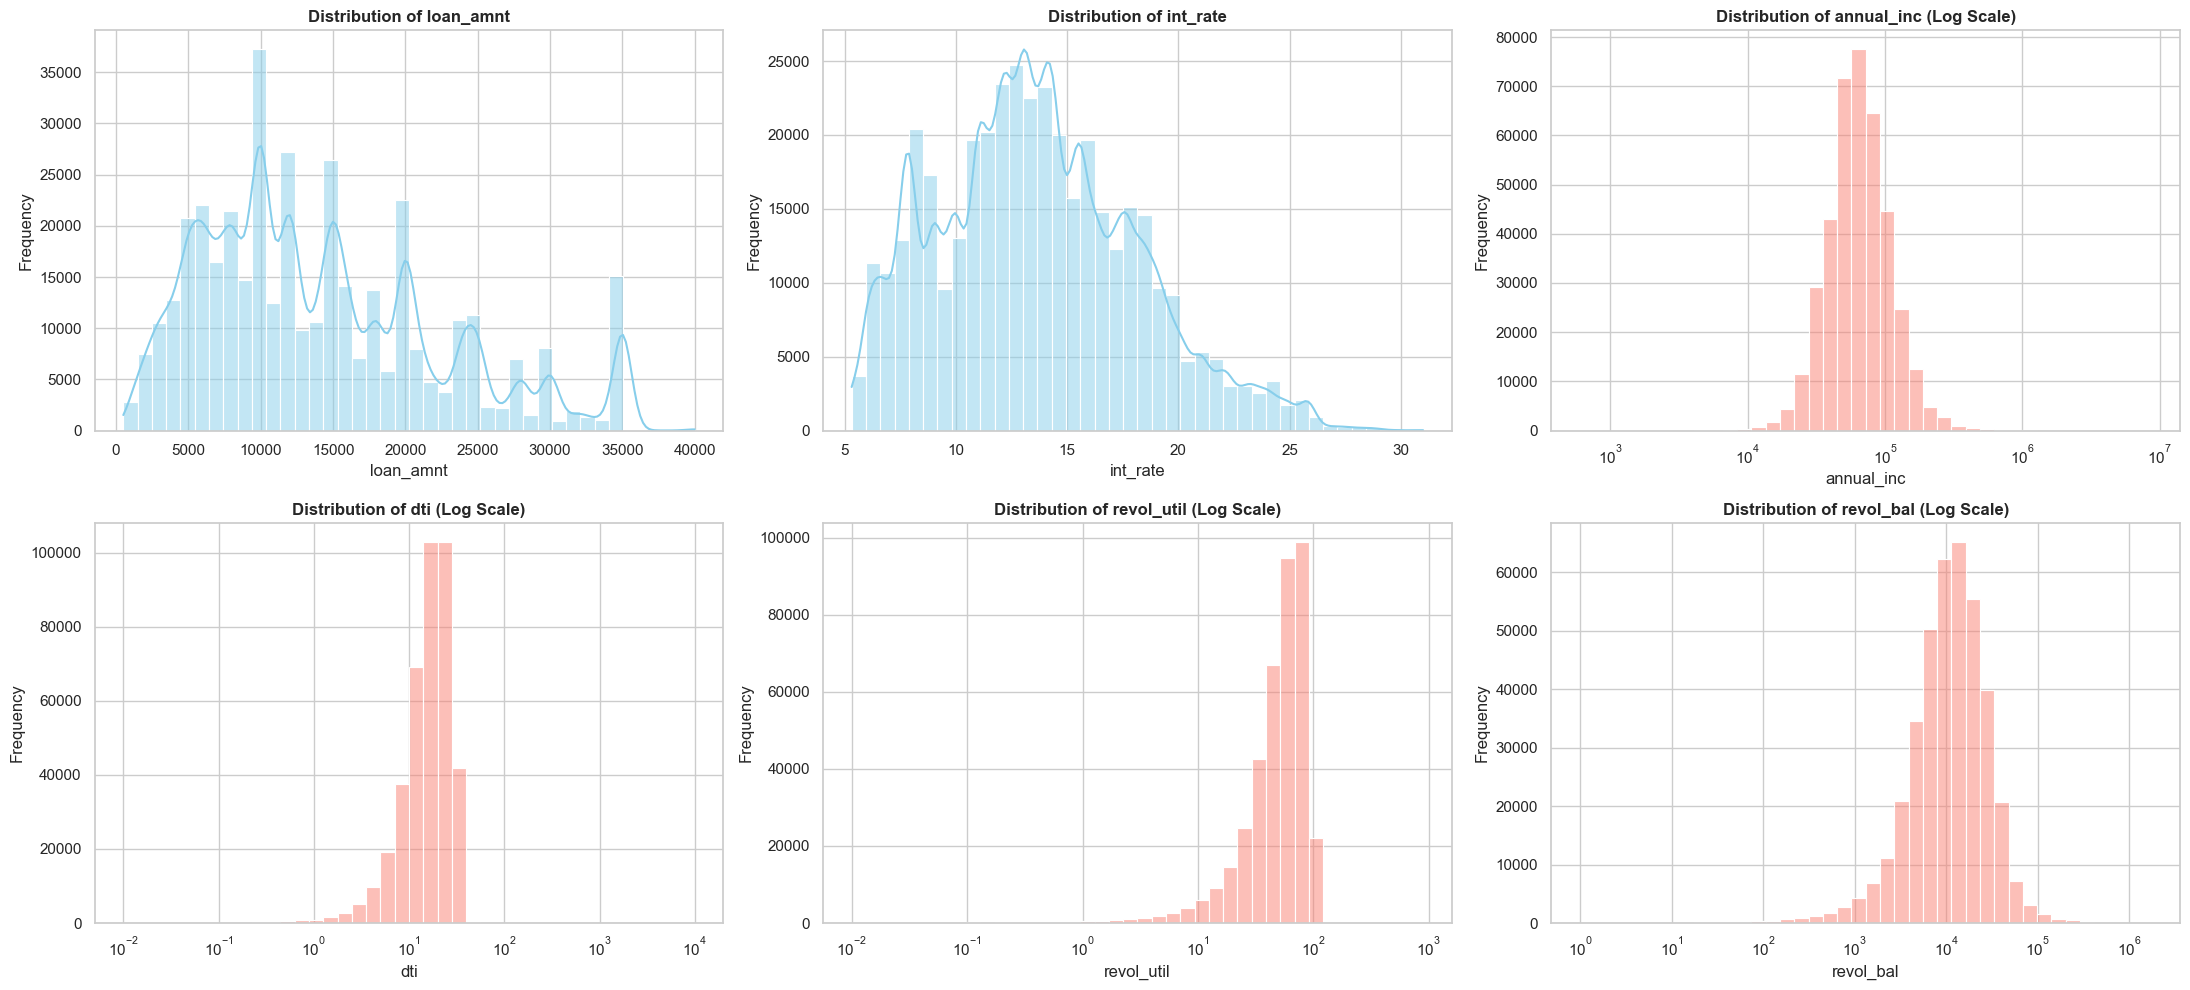

In [54]:
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10
cont_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util', 'revol_bal']
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
axes = axes.flatten()
for index, col in enumerate(cont_features):
    # Log-scale visualization for extreme right-skewed features
    if col in ['annual_inc', 'revol_bal', 'dti', 'revol_util']:
        sns.histplot(df[col], kde = True, ax=axes[index], color='salmon', bins=40, log_scale=True)
        axes[index].set_title(f'Distribution of {col} (Log Scale)', fontsize=12, fontweight='bold')
    else:
        sns.histplot(df[col], kde=True, ax=axes[index], color='skyblue', bins=40)
        axes[index].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[index].set_xlabel(col)
    axes[index].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


### Visual Insights: Continuous Features (Univariate Analysis)

* **`loan_amnt` (Loan Amount):** Borrowers prefer round numbers. The sharpest peaks appear at **\$10,000**, **\$15,000**, **\$20,000**, and **\$35,000**, with most loans ranging between \$5,000 and \$20,000.
* **`int_rate` (Interest Rate):** Shows multiple peaks (around **10%**, **13%**, and **15%**). This happens because LoanTap assigns interest rates in fixed slabs based on the borrower's credit grade.
* **`annual_inc` (Annual Income - Log Scale):** Most applicants earn around **\$64,000 per year**. The log transformation turns extreme income outliers into a clean, bell-shaped normal curve.
* **`dti` (Debt-to-Income Ratio - Log Scale):** Most borrowers spend **10% to 25%** of their monthly income on existing debt payments. Extreme values over $100$ indicate data entry errors that must be capped.
* **`revol_util` (Revolving Credit Utilization - Log Scale):** Most people use **30% to 80%** of their available credit limit, peaking near **60% to 70%**. Values above 100% indicate applicants who have maxed out their credit cards.
* **`revol_bal` (Revolving Credit Balance - Log Scale):** Most borrowers carry an active credit balance between **\$5,000 and \$25,000**, forming a clean normal distribution on the log scale centered around \$11,000.

### 1.3.2 Univariate Analysis for Categorical Features

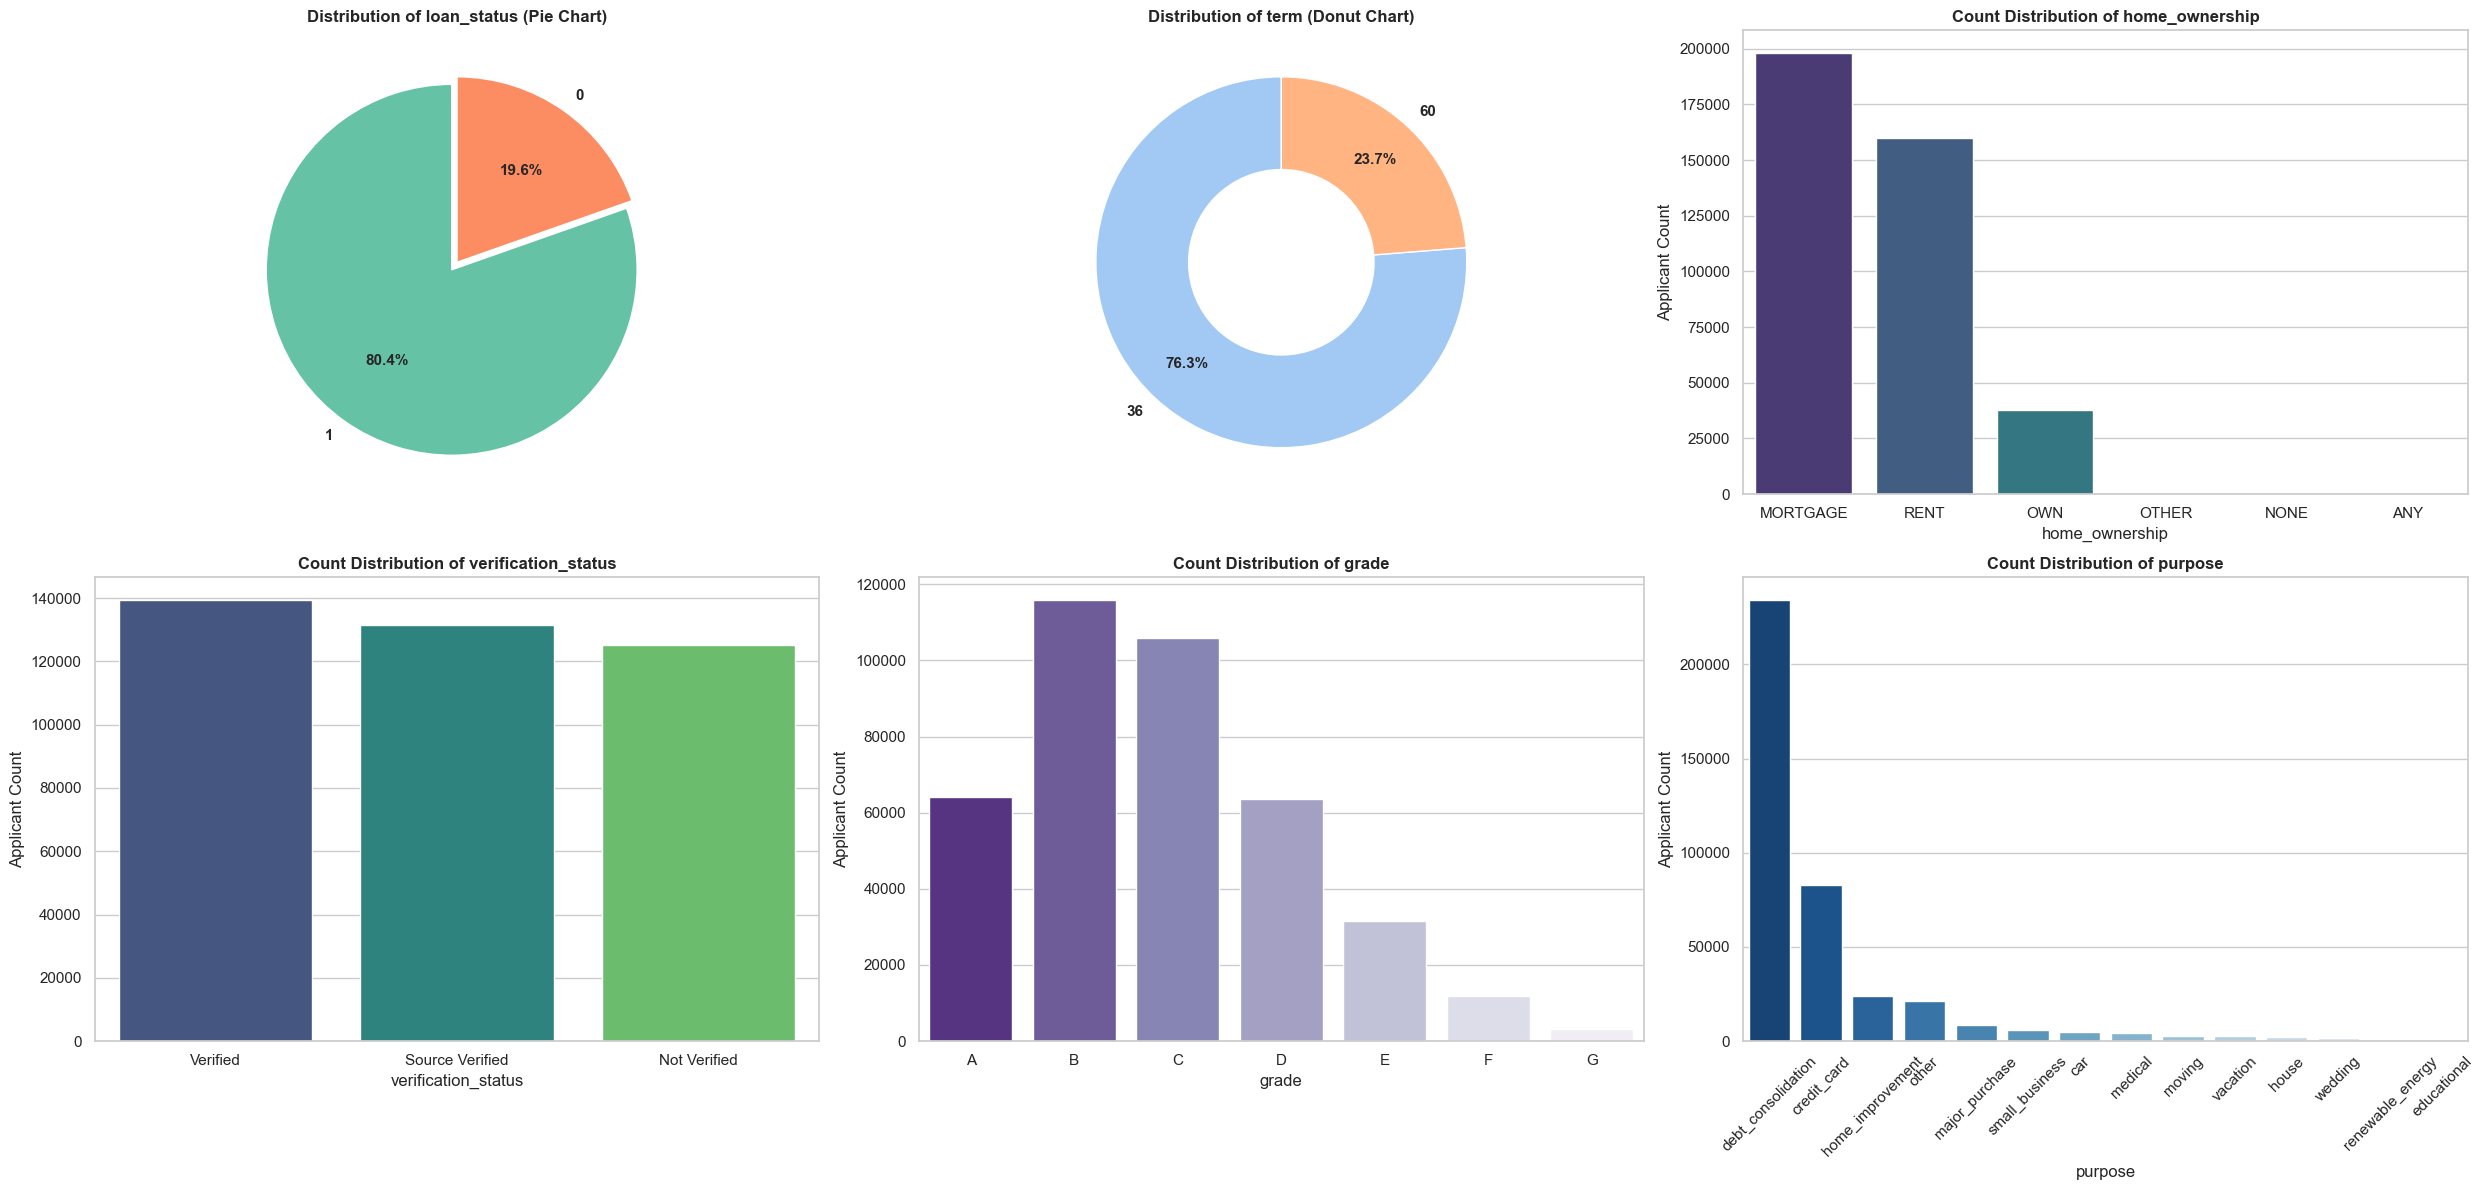

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(25, 12))
axes = axes.flatten()
# 1. PIE CHART: loan_status
loan_status_counts = df['loan_status'].value_counts()
colors_pie = sns.color_palette('Set2')[0:len(loan_status_counts)]

axes[0].pie(
    loan_status_counts, 
    labels=loan_status_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors_pie,
    explode=(0.05, 0),
    textprops={'fontsize': 11, 'weight': 'bold'}
)
axes[0].set_title('Distribution of loan_status (Pie Chart)', fontsize=12, fontweight='bold')

# 2. DONUT CHART: term
term_counts = df['term'].value_counts()
colors_donut = sns.color_palette('pastel')[0:len(term_counts)]

axes[1].pie(
    term_counts, 
    labels=term_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors_donut,
    pctdistance=0.75,
    textprops={'fontsize': 11, 'weight': 'bold'}
)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Distribution of term (Donut Chart)', fontsize=12, fontweight='bold')

# 3. COUNT PLOTS: home_ownership, verification_status, grade, purpose
remaining_cat = ['home_ownership', 'verification_status', 'grade', 'purpose']
for i, col in enumerate(remaining_cat):
    ax_idx = i + 2  
    
    if col == 'purpose':
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, ax=axes[ax_idx], palette='Blues_r', order=order)
        axes[ax_idx].tick_params(axis='x', rotation=45)
    elif col == 'grade':
        order = sorted(df[col].dropna().unique())
        sns.countplot(data=df, x=col, ax=axes[ax_idx], palette='Purples_r', order=order)
    else:
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, ax=axes[ax_idx], palette='viridis', order=order)
        
    axes[ax_idx].set_title(f'Count Distribution of {col}', fontsize=12, fontweight='bold')
    axes[ax_idx].set_xlabel(col)
    axes[ax_idx].set_ylabel('Applicant Count')

plt.tight_layout()
plt.show()

### Visual Insights: Categorical Features (Univariate Analysis)

* **`loan_status` (Pie Chart):** Shows class imbalance where **80.4%** of loans are `1` (Fully Paid) and **19.6%** are `0` (Charged Off / Defaulted). Model evaluation must prioritize Recall over raw accuracy.
* **`term` (Donut Chart):** Over three-quarters of applicants (**76.3%**) choose a **36-month loan term**, while only **23.7%** pick a 60-month tenure.
* **`home_ownership`:** The vast majority of applicants either carry a **MORTGAGE** (~198k) or **RENT** (~160k). Those who own their home outright (**OWN**) represent a small minority (~37k).
* **`verification_status`:** Applications are evenly split across all three buckets (`Verified`, `Source Verified`, and `Not Verified`), each hovering between 125,000 and 140,000 applicants.
* **`grade`:** Most loans are concentrated in **Grade B** (~115k) and **Grade C** (~105k), representing LoanTap's core customer base. High-risk grades (**F** and **G**) make up a very small portion of total volume.
* **`purpose`:** **`debt_consolidation`** is by far the single largest reason for borrowing (>230k applicants), followed by **`credit_card`** payoff. All other reasons combined make up a negligible fraction.

## 1.4 Bivariate Analysis

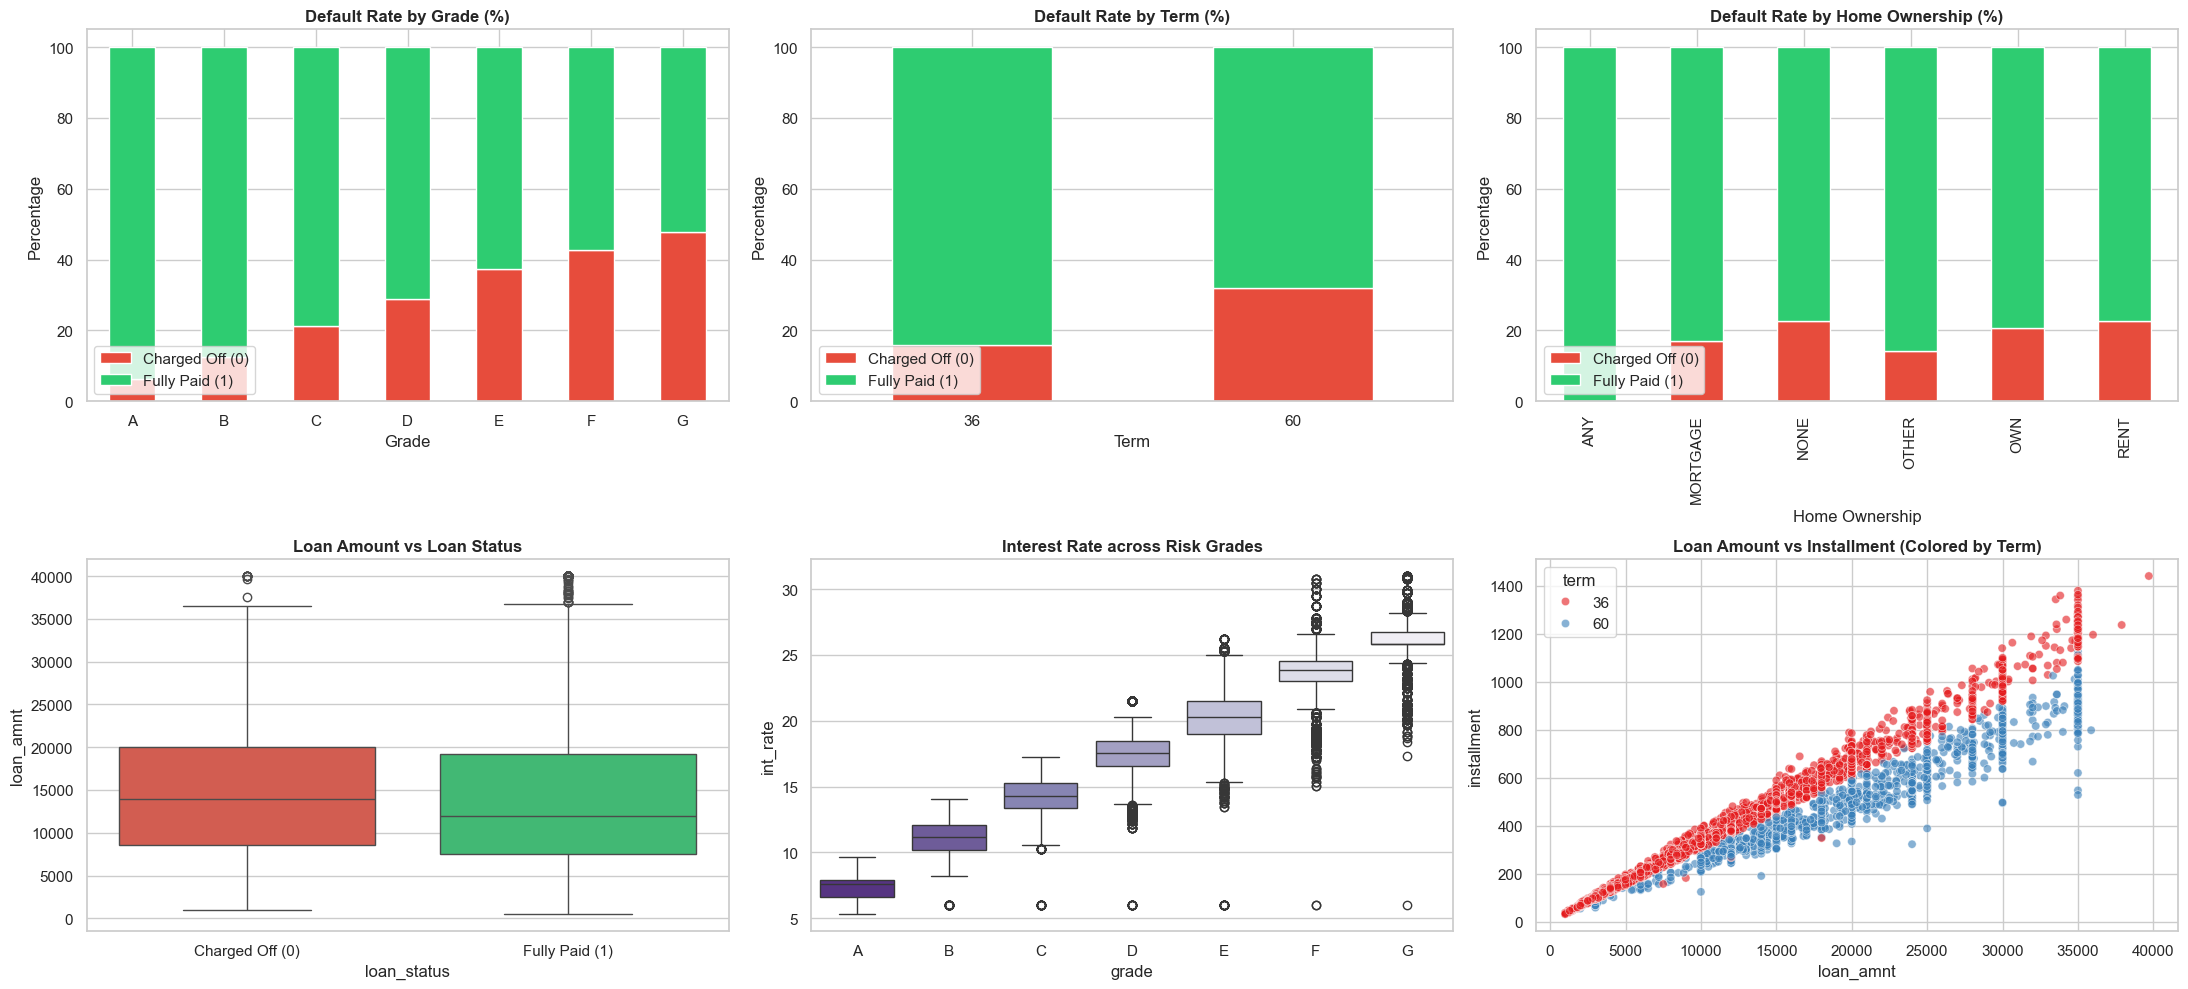

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
axes = axes.flatten()
# 1. CATEGORICAL VS TARGET (Default Rate Stacked Bar Plots)
# Grade vs Loan Status
grade_ct = pd.crosstab(df['grade'], df['loan_status'], normalize='index') * 100
grade_ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Default Rate by Grade (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('Grade')
axes[0].legend(['Charged Off (0)', 'Fully Paid (1)'], loc='lower left')
axes[0].tick_params(axis='x', rotation=0)

# Term vs Loan Status
term_ct = pd.crosstab(df['term'], df['loan_status'], normalize='index') * 100
term_ct.plot(kind='bar', stacked=True, ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Default Rate by Term (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Term')
axes[1].legend(['Charged Off (0)', 'Fully Paid (1)'], loc='lower left')
axes[1].tick_params(axis='x', rotation=0)

# Home Ownership vs Loan Status
home_ct = pd.crosstab(df['home_ownership'], df['loan_status'], normalize='index') * 100
home_ct.plot(kind='bar', stacked=True, ax=axes[2], color=['#e74c3c', '#2ecc71'])
axes[2].set_title('Default Rate by Home Ownership (%)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Percentage')
axes[2].set_xlabel('Home Ownership')
axes[2].legend(['Charged Off (0)', 'Fully Paid (1)'], loc='lower left')

# 2. CATEGORICAL VS CONTINUOUS (Boxplots)
# Loan Amount by Loan Status
sns.boxplot(data=df, x='loan_status', y='loan_amnt', ax=axes[3], palette=['#e74c3c', '#2ecc71'])
axes[3].set_title('Loan Amount vs Loan Status', fontsize=12, fontweight='bold')
axes[3].set_xticklabels(['Charged Off (0)', 'Fully Paid (1)'])

# Interest Rate by Grade
grade_order = sorted(df['grade'].dropna().unique())
sns.boxplot(data=df, x='grade', y='int_rate', order=grade_order, ax=axes[4], palette='Purples_r')
axes[4].set_title('Interest Rate across Risk Grades', fontsize=12, fontweight='bold')

# 3. CONTINUOUS VS CONTINUOUS (Scatterplot)
# Loan Amount vs Installment (Sampled 5,000 points to avoid overplotting)
sns.scatterplot(
    data=df.sample(5000, random_state=42), 
    x='loan_amnt', y='installment', hue='term', 
    ax=axes[5], alpha=0.6, palette='Set1'
)
axes[5].set_title('Loan Amount vs Installment (Colored by Term)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Visual Insights: Bivariate Analysis

* **Grade:** Default rates rise monotonically from **Grade A (~6%)** to **Grade G (~50%)**, confirming credit grade as a primary risk driver.
* **Term:** **60-month terms** default at twice the rate of **36-month terms (~32% vs ~16%)**, showing extended tenure significantly increases default exposure.
* **Home Ownership:** **Renters** display the highest default rate (~22%), while **Mortgage holders** show the lowest (~17%), reflecting greater asset stability.
* **Loan Amount:** Defaulted loans have a slightly higher median principal (~$14,000 vs ~$12,000), indicating larger debt burdens elevate risk.
* **Interest Rate:** Median rates step up predictably from **Grade A (~7%)** to **Grade G (~26%)**, confirming risk-based pricing alignment.
* **Correlation:** Strong linear relationship ($r > 0.95$) between `loan_amnt` and `installment` introduces high multicollinearity for logistic regression.

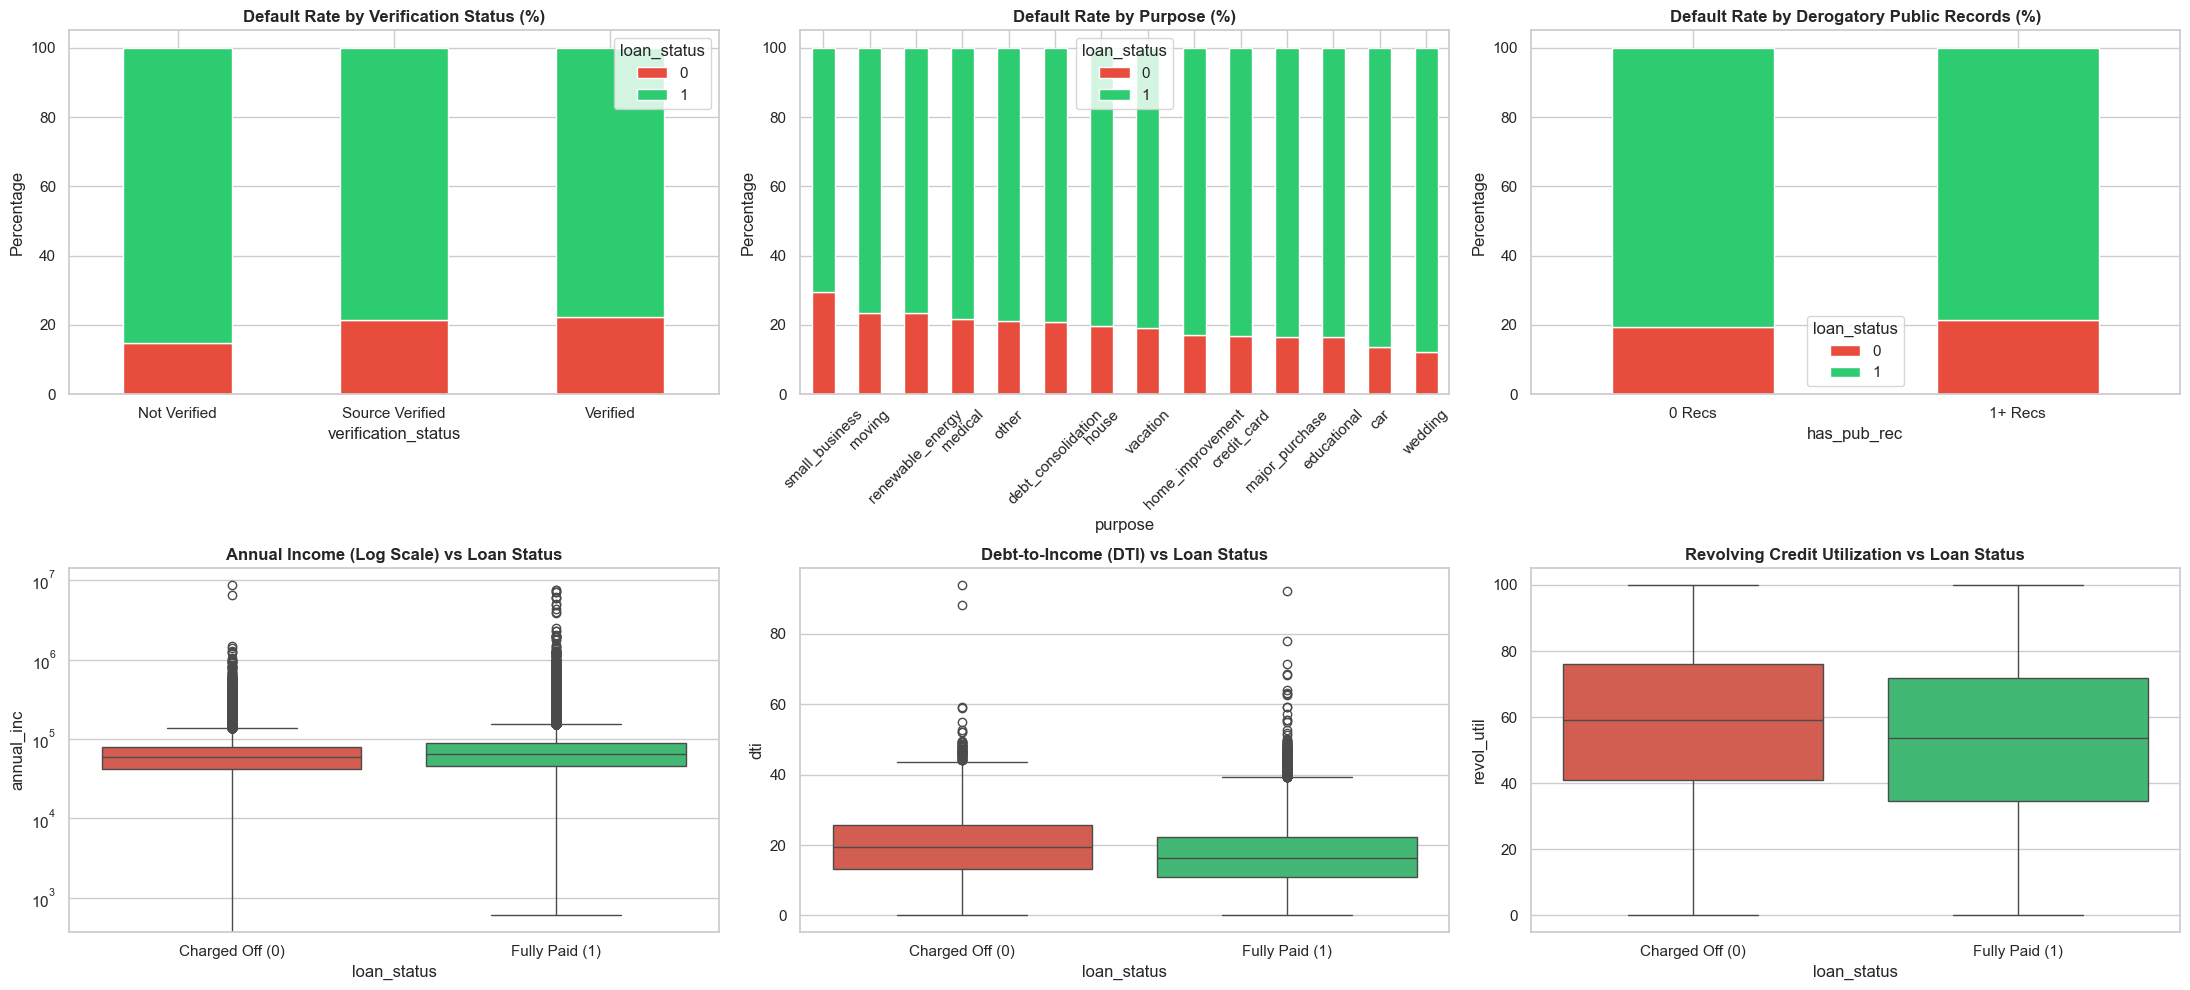

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
axes = axes.flatten()
# 1. CATEGORICAL VS TARGET (Crosstabs / Stacked Bars)
# Verification Status vs Loan Status
ver_ct = pd.crosstab(df['verification_status'], df['loan_status'], normalize='index') * 100
ver_ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Default Rate by Verification Status (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].tick_params(axis='x', rotation=0)

# Loan Purpose vs Loan Status
purpose_ct = pd.crosstab(df['purpose'], df['loan_status'], normalize='index') * 100
purpose_sort = purpose_ct.sort_values(by=0, ascending=False) 
purpose_sort.plot(kind='bar', stacked=True, ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Default Rate by Purpose (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=45)

# Public Records Flag vs Loan Status
df_temp = df.copy()
df_temp['has_pub_rec'] = np.where(df_temp['pub_rec'] > 0, '1+ Recs', '0 Recs')
pub_ct = pd.crosstab(df_temp['has_pub_rec'], df_temp['loan_status'], normalize='index') * 100
pub_ct.plot(kind='bar', stacked=True, ax=axes[2], color=['#e74c3c', '#2ecc71'])
axes[2].set_title('Default Rate by Derogatory Public Records (%)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Percentage')
axes[2].tick_params(axis='x', rotation=0)

# 2. CONTINUOUS VS TARGET (Boxplots)
# Annual Income (Log Scale) by Loan Status
sns.boxplot(data=df, x='loan_status', y='annual_inc', ax=axes[3], palette=['#e74c3c', '#2ecc71'])
axes[3].set_yscale('log')
axes[3].set_title('Annual Income (Log Scale) vs Loan Status', fontsize=12, fontweight='bold')
axes[3].set_xticklabels(['Charged Off (0)', 'Fully Paid (1)'])

# DTI by Loan Status (Filtered < 100 to remove extreme outliers)
sns.boxplot(data=df[df['dti'] < 100], x='loan_status', y='dti', ax=axes[4], palette=['#e74c3c', '#2ecc71'])
axes[4].set_title('Debt-to-Income (DTI) vs Loan Status', fontsize=12, fontweight='bold')
axes[4].set_xticklabels(['Charged Off (0)', 'Fully Paid (1)'])

# Revolving Utilization by Loan Status
sns.boxplot(data=df[df['revol_util'] <= 100], x='loan_status', y='revol_util', ax=axes[5], palette=['#e74c3c', '#2ecc71'])
axes[5].set_title('Revolving Credit Utilization vs Loan Status', fontsize=12, fontweight='bold')
axes[5].set_xticklabels(['Charged Off (0)', 'Fully Paid (1)'])

plt.tight_layout()
plt.show()

### Visual Insights: Additional Bivariate Analysis

* **Verification Status:** **Verified applicants (~22%)** default more than **Not Verified (~14%)**, reflecting selection bias where stricter verification is targeted at higher-risk applicants.
* **Loan Purpose:** **`small_business` loans** carry the highest default rate (~30%), while personal asset loans (**`car`**, **`wedding`**) show the lowest failure rates.
* **Public Records:** Borrowers with **1+ derogatory records** show elevated default rates (~22% vs ~19%), validating public records as a reliable risk marker.
* **Annual Income:** **Fully Paid** borrowers exhibit higher median income, confirming that earnings buffer against debt servicing failure.
* **Debt-to-Income (DTI):** Defaulted borrowers display a higher median **DTI (~19.5% vs ~16.8%)**, showing leverage strain directly drives default likelihood.
* **Credit Utilization:** Defaulted borrowers carry higher median utilization **(~59% vs ~53%)**, indicating active liquidity stress prior to default.

## 1.5 Range of Attributes and Outliers

### 1.5.1 Range of numerical variables and IQR Outlier Detection

In [58]:
## Range of numerical variables
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

range_summary = pd.DataFrame({
    'Minimum': df[numeric_cols].min(),
    'Maximum': df[numeric_cols].max(),
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median()
})

range_summary

,Minimum,Maximum,Mean,Median
loan_amnt,500.00,40000.00,14113.888089,12000.00
term,36.00,60.00,41.698053,36.00
int_rate,5.32,30.99,13.639400,13.33
installment,16.08,1533.81,431.849698,375.43
annual_inc,0.00,8706582.00,74203.175798,64000.00
loan_status,0.00,1.00,0.803871,1.00
dti,0.00,9999.00,17.379514,16.91
open_acc,0.00,90.00,11.311153,10.00
pub_rec,0.00,86.00,0.178191,0.00
revol_bal,0.00,1743266.00,15844.539853,11181.00


In [59]:
## IQR Outlier Detection
outlier_summary = []
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outlier_count = (
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ).sum()
    outlier_percentage = (
        outlier_count / len(df) * 100
    )
    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Limit': lower_limit,
        'Upper Limit': upper_limit,
        'Outlier Count': outlier_count,
        'Outlier %': outlier_percentage
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    'Outlier %',
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Limit,Upper Limit,Outlier Count,Outlier %
1,term,36.00,36.00,0.00,36.000,36.000,94025,23.741888
5,loan_status,1.00,1.00,0.00,1.000,1.000,77673,19.612908
8,pub_rec,0.00,0.00,0.00,0.000,0.000,57758,14.584249
13,pub_rec_bankruptcies,0.00,0.00,0.00,0.000,0.000,45115,11.391814
9,revol_bal,6025.00,19620.00,13595.00,-14367.500,40012.500,21259,5.368028
4,annual_inc,45000.00,90000.00,45000.00,-22500.000,157500.000,16700,4.216852
3,installment,250.33,567.30,316.97,-225.125,1042.755,11250,2.840694
7,open_acc,8.00,14.00,6.00,-1.000,23.000,10307,2.602581
11,total_acc,17.00,32.00,15.00,-5.500,54.500,8499,2.146050
12,mort_acc,0.00,3.00,3.00,-4.500,7.500,6843,1.727899


### Summary of IQR Outlier Analysis & Insights

* **`term` (23.74%) & `loan_status` (19.61%):** Zero IQR ($Q1=Q3$) mechanically flags minority classes (60-month terms and Charged Off status) as outliers.
* **`pub_rec` (14.58%) & `pub_rec_bankruptcies` (11.39%):** Zero-inflated distributions ($Q1=Q3=0$) turn $\ge 1$ derogatory flags into statistical outliers, representing genuine credit risk.
* **`revol_bal` (5.37%) & `annual_inc` (4.22%):** Heavy right-skewed tails reflect legitimate high-income and high-credit balance borrowers rather than data errors.
* **`installment` (2.84%) & `loan_amnt` (0.05%):** Upper-tail entries represent max-tier credit requests capped near LoanTap’s $40k policy limit.
* **`open_acc` (2.60%), `total_acc` (2.15%), & `mort_acc` (1.73%):** High account counts reflect deep credit history and real estate activity rather than anomalies.
* **`int_rate` (0.95%):** Extreme rates ($>25.49\%$) belong exclusively to high-risk credit sub-grades (Grades F/G), reflecting risk-based pricing.
* **`revol_util` (0.003%) & `dti` (0.07%):** Low occurrence but extreme values (DTI near 9,999; utilization ~900%) signal clear system logging errors or penalty states.

### 1.5.2 Outlier Visual Analysis

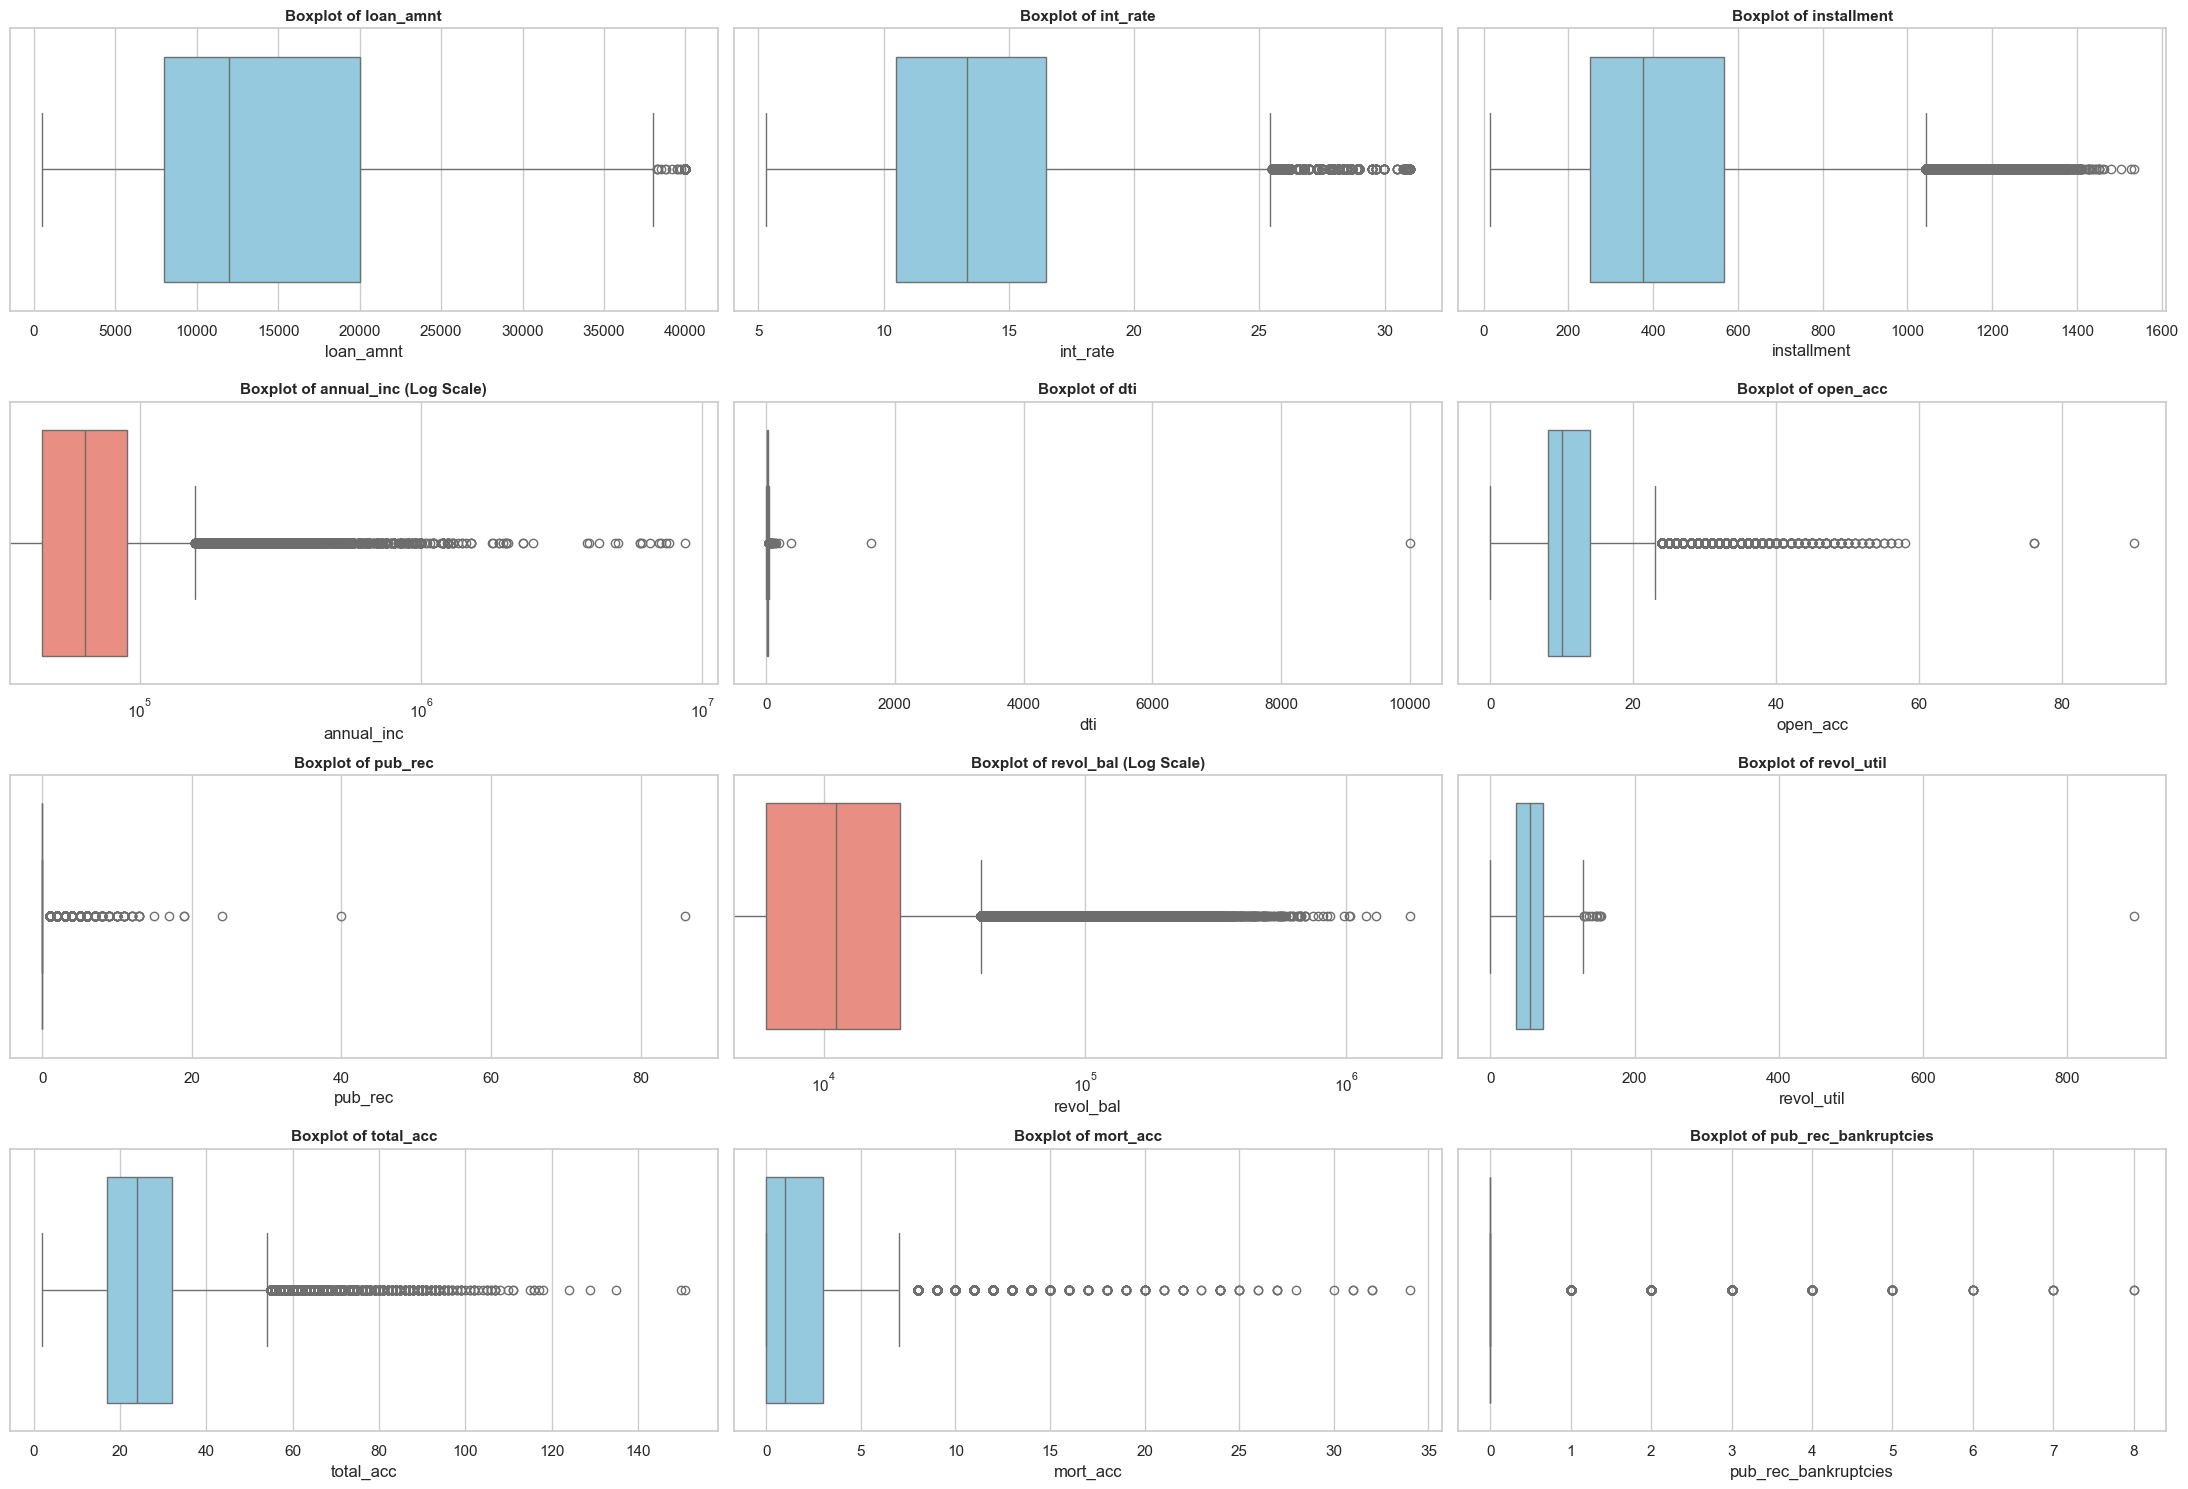

In [60]:
num_features = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 
    'dti', 'open_acc', 'pub_rec', 'revol_bal', 
    'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies'
]
fig, axes = plt.subplots(4, 3, figsize=(22, 15))
axes = axes.flatten()

for index, col in enumerate(num_features):
    if col in ['annual_inc', 'revol_bal']:
        sns.boxplot(data=df, x=col, ax=axes[index], color='salmon')
        axes[index].set_xscale('log')
        axes[index].set_title(f'Boxplot of {col} (Log Scale)', fontsize=11, fontweight='bold')
    else:
        sns.boxplot(data=df, x=col, ax=axes[index], color='skyblue')
        axes[index].set_title(f'Boxplot of {col}', fontsize=11, fontweight='bold')
    
    axes[index].set_xlabel(col)

plt.tight_layout()
show_plot = True  
plt.show()

### Visual Insights: Numerical Features Boxplots (Outlier & Distribution Analysis)

* **`loan_amnt`:** Median at **~$12,000** (IQR: $7.5k–$20k); bounded between $1k and the $40k policy cap with zero extreme outliers.
* **`int_rate`:** Centered at **~13.5%** (IQR: 10%–16.5%); upper-tail outliers (>25%) reflect high-risk sub-grades (Grades F/G).
* **`installment`:** Median of **~$375** (IQR: $240–$560); upper outliers (>$1,000/mo) correlate directly with max principal approvals ($35k–$40k).
* **`annual_inc` (Log Scale):** Log scaling centers earnings (IQR: $45k–$90k); right-tail outliers represent valid high-net-worth applicants.
* **`dti`:** Median sits at **~17.5%**; severe extreme outliers (up to 10,000) represent bad data logging requiring capping at $\text{DTI} \le 100$.
* **`open_acc`:** Typical applicants hold **8–14 active lines** (Median: 10); upper outliers (>23 lines) reflect highly active credit users.
* **`pub_rec`:** Zero-inflated (IQR collapsed at 0); outliers up to 80+ records should be converted to a binary flag ($0$ vs $\ge 1$).
* **`revol_bal` (Log Scale):** Log distribution centers at a median balance of **~$11,000** (IQR: $6k–$20k), controlling $1M+ outliers.
* **`revol_util`:** Median sits at **~54%** (IQR: 34%–73%); over-limit outliers (>100% up to 900%) should be capped at 100%.
* **`total_acc`:** Median sit at **24 accounts** (IQR: 16–33); upper outliers (>50 lines) indicate mature credit profiles.
* **`mort_acc`:** Zero-inflated (Median: 1, IQR: 0–3); upper outliers ($\ge 7$) capture real estate investors and multi-property owners.
* **`pub_rec_bankruptcies`:** Zero-inflated (Q1–Q3 = 0); discrete values (1–8) should be binarized into $0$ vs $\ge 1$ flags.

## 1.6 Correlation Analysis

<Axes: >

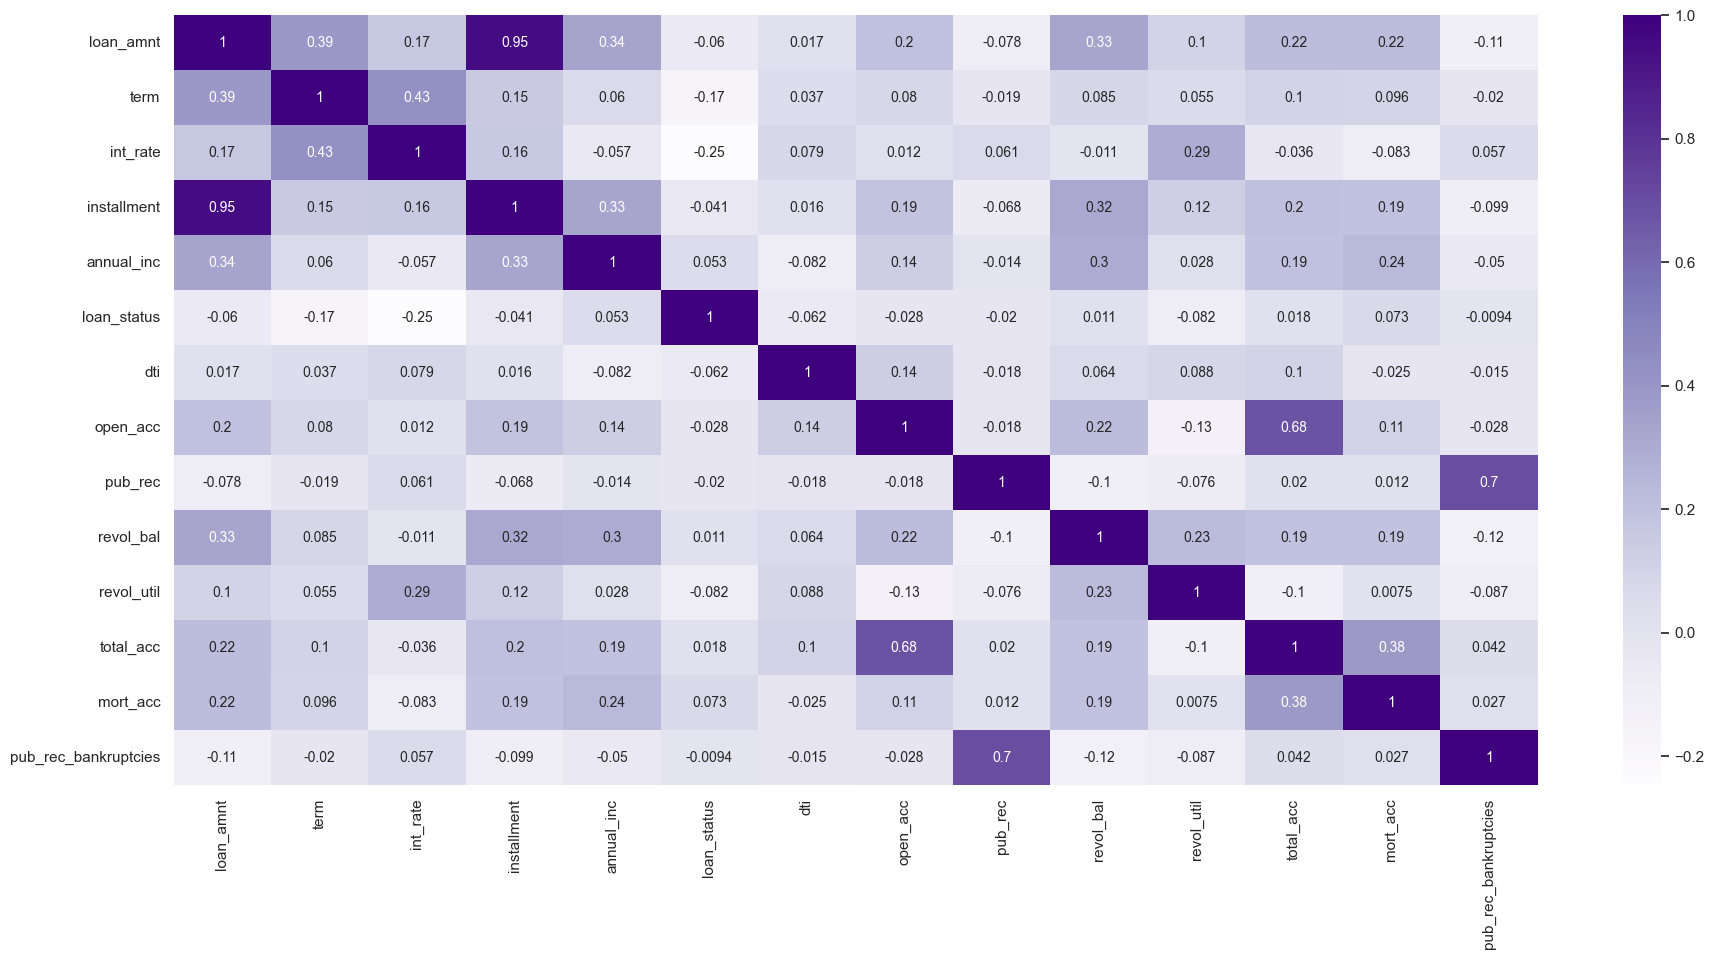

In [61]:
plt.figure(figsize=(22, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Purples")

### Visual Insights: Heatmap Correlation Matrix & Analysis

* **`loan_amnt` vs `installment` ($r = 0.95$):** Extremely high correlation driven by amortization math; introduces severe multicollinearity in linear models.
* **`pub_rec` vs `pub_rec_bankruptcies` ($r = 0.70$):** Strong overlap as bankruptcies form part of public records; can be consolidated into a composite binary feature.
* **`open_acc` vs `total_acc` ($r = 0.68$):** Moderate collinearity; engineering an $\text{open\_acc} / \text{total\_acc}$ ratio better captures active credit utilization behavior.
* **`int_rate` vs `term` ($r = 0.43$):** Moderate correlation; 60-month terms carry higher interest rates to compensate for extended time-horizon risk.
* **`int_rate` vs `loan_status` ($r = -0.25$):** Strongest target predictor; higher rates increase monthly burden and default likelihood.
* **`annual_inc` vs `loan_amnt` ($r = 0.34$):** Moderate positive relationship; underwriting caps approval amounts based on applicant earnings.

## 1.7 Normal vs Skewed Distributions

In [62]:
skewness = df[numeric_cols].skew().sort_values()

In [63]:
skewness_summary = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values
})
skewness_summary

,Feature,Skewness
0,loan_status,-1.530582
1,revol_util,-0.071778
2,int_rate,0.420669
3,loan_amnt,0.777285
4,total_acc,0.864328
5,installment,0.983598
6,open_acc,1.213019
7,term,1.234225
8,mort_acc,1.600132
9,pub_rec_bankruptcies,3.423440


### Visual Insights: Feature Skewness & Underlying Drivers

* **`loan_status` (-1.53):** Highly left-skewed due to ~80% class imbalance toward fully paid loans (`1`).
* **`revol_util` (-0.07) & `int_rate` (0.42):** Near-symmetric; rates span risk tiers evenly, and utilization centers around normal credit usage.
* **`loan_amnt` (0.78) & `installment` (0.98):** Moderately right-skewed; applicants cluster at modest principals with fewer max-limit requests ($40k).
* **`open_acc` (1.21) & `term` (1.23):** Right-skewed; driven by standard baseline account counts and the dominance of 36-month loan terms.
* **`mort_acc` (1.60) & `pub_rec_bankruptcies` (3.42):** Highly right-skewed due to heavy zero-inflation (most applicants have 0 flags).
* **`revol_bal` (11.73) & `annual_inc` (41.04):** Extreme positive skew following power-law wealth and balance distributions.
* **`dti` (431.05):** Exceptionally distorted by severe high-value data-entry errors (reaching up to 9.999%).

## 2. Data Preprocessing

## 2.1 Duplicate Values Check

### 2.1.1 Full row duplicates

In [64]:
print("Duplicate Values:", df.duplicated().sum())

Duplicate Values: 0


    Zero duplicate values for the entire data.

### 2.1.2 Subset Duplicates

In [65]:
subset_cols = ["loan_amnt", "annual_inc", "dti", "open_acc", "revol_bal"]
subset_duplicates = df.duplicated(subset=subset_cols).sum()
print("Subset Duplicates (Potential Repeated Profiles):", subset_duplicates)

Subset Duplicates (Potential Repeated Profiles): 4


In [66]:
df = df.drop_duplicates(subset=subset_cols).reset_index(drop=True)

### Subset Duplicate Removal & Feature Selection Rationale

* **Duplicates Identified & Action:** Dropped **4 duplicate records** matching across core financial attributes (`loan_amnt`, `annual_inc`, `dti`, `open_acc`, `revol_bal`) to prevent data leakage and train-test evaluation bias.
* **Selection Rationale:** Combining precise continuous variables creates a unique financial fingerprint, isolating duplicate submissions while excluding broad categorical metrics (`purpose`, `term`) that thousands of unrelated borrowers share.

## 2.2 Missing Values Treatment

### 2.2.1 Identifying missing values and percentages.

In [67]:
## Missing Summary

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Precentage": (df.isnull().sum() / len(df)) * 100
}).query("Missing_Count > 0").sort_values(by="Missing_Count", ascending=False)
missing_summary

,Missing_Count,Missing_Precentage
mort_acc,37791,9.542555
emp_title,22926,5.789014
emp_length,18301,4.621161
title,1756,0.443405
pub_rec_bankruptcies,535,0.135092
revol_util,276,0.069692


    These are the columns that have missing values, in which mort_acc have the highest percentage among all of them.

### 2.2.2 Imputation of missing values based on smart strategies

In [68]:
## 1. mort_acc
if "mort_acc" in df.columns and df["mort_acc"].isnull().sum() > 0:
    total_acc_avg = df.groupby("total_acc")["mort_acc"].median()
    df["mort_acc"] = df.apply(
        lambda row: total_acc_avg.get(row["total_acc"], df["mort_acc"].median())
        if pd.isnull(row["mort_acc"]) else row["mort_acc"], axis = 1
    )

* **`mort_acc` (Group-wise Median Imputation):** 
  * **Strategy:** Imputed missing values using the median `mort_acc` grouped by the borrower's total number of credit lines (`total_acc`).
  * **Why:** `mort_acc` shares a strong positive correlation ($r = 0.38$) with `total_acc`. Borrowers with more overall credit accounts naturally hold more mortgage accounts. Global mean/median imputation would introduce bias by ignoring individual credit maturity.

In [69]:
## 2. revol_util
if "revol_util" in df.columns and df["revol_util"].isnull().sum() > 0:
    df["revol_util"] = df["revol_util"].fillna(df["revol_util"].median())

In [70]:
## 3. pub_rec_bankruptcies
if "pub_rec_bankruptcies" in df.columns and df["pub_rec_bankruptcies"].isnull().sum() > 0:
    df["pub_rec_bankruptcies"] = df["pub_rec_bankruptcies"].fillna(0.0)

In [71]:
## 4. emp_length & emp_title
if "emp_length" in df.columns and df["emp_length"].isnull().sum() > 0:
    df["emp_length"] = df["emp_length"].astype(str).replace('nan', np.nan).fillna("Unknown").astype("category")

if "emp_title" in df.columns and df["emp_title"].isnull().sum() > 0:
    df["emp_title"] = df["emp_title"].astype(str).replace('nan', np.nan).fillna("Unknown").astype("category")


* **`emp_length` & `emp_title` (Categorical 'Unknown' Encoding):** 
  * **Strategy:** Categorized missing entries under a distinct `'Unknown'` label.
  * **Why:** Employment details may be omitted by self-employed individuals, freelancers, or unverified applicants. Dropping these rows would result in losing valid loan data, while forcing a mode replacement (like `'10+ years'`) would create artificial bias.

In [72]:
## 5. title
if 'title' in df.columns and df['title'].isnull().sum() > 0:
    df['title'] = df['title'].fillna('Unknown')

    Missing Values Treatment is done.

## 2.3 Outlier Treatment

### 2.3.1 Outlier Dataframe

In [73]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_limit) |(df[col] > upper_limit))

    outlier_summary.append({
        'Feature': col,
        'Outlier Count': outliers.sum(),
        'Outlier %': outliers.mean() * 100
    })
outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    'Outlier %',
    ascending=False
)

,Feature,Outlier Count,Outlier %
1,term,94024,23.741876
5,loan_status,77673,19.613106
8,pub_rec,57758,14.584396
13,pub_rec_bankruptcies,45115,11.391929
9,revol_bal,21259,5.368082
4,annual_inc,16700,4.216895
3,installment,11250,2.840723
7,open_acc,10307,2.602607
11,total_acc,8499,2.146071
12,mort_acc,6843,1.727917


### Summary of IQR Outlier Table & Specific Treatment Actions

* **Categorical Artifacts (`term`, `loan_status` | 19.6%–23.7% Outliers):** **Retain As-Is.** Zero IQR ($Q1=Q3$) mechanically flags valid minority classes (60-month terms, Charged Off status) as statistical outliers.
* **Zero-Inflated Risk Signals (`pub_rec`, `pub_rec_bankruptcies` | 11.4%–14.6% Outliers):** **Convert to Binary Flags.** Over 85% of records sit at 0; values $\ge 1$ represent genuine credit risk signals rather than data errors.
* **Monetary / Balance Skew (`annual_inc`, `revol_bal` | 4.2%–5.4% Outliers):** **Apply Log Transformation ($\log(1+x)$).** Compresses long right-tail wealth distributions without dropping high-value borrowers.
* **Policy-Capped Metrics (`installment`, `loan_amnt`, `int_rate` | 0.5%–2.8% Outliers):** **Retain As-Is.** Upper values represent valid high-tier products bounded by the $40k loan cap and high-risk interest sub-grades (F/G).
* **Credit History Maturity (`open_acc`, `total_acc`, `mort_acc` | 1.7%–2.6% Outliers):** **Retain As-Is.** Reflects mature credit histories and multi-property holders; handled well by tree models and scaling.
* **Severe Operational Ratios (`dti`, `revol_util` | 0.003%–0.07% Outliers):** **Cap Upper Bound at 100%.** Extreme values ($\text{DTI} > 1,000$, $\text{utilization} > 800\%$) represent penalty states or logging anomalies requiring capping.

### 2.3.2 Handling Outliers

In [ ]:
## 1. Capping
iqr_cap_cols = ["dti", "revol_util"]
for col in iqr_cap_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

In [ ]:
## 2. Log Transformation
df['annual_inc'] = np.log1p(df['annual_inc'])
df['revol_bal'] = np.log1p(df['revol_bal'])

In [76]:
print("Post-Treatment Max Values:")
print(f"Max DTI: {df['dti'].max()}")
print(f"Max Revol Utilization: {df['revol_util'].max()}%")
print(f"Max Log Income: {df['annual_inc'].max():.2f}")
print(f"Max Log Revol Bal: {df['revol_bal'].max():.2f}")

Post-Treatment Max Values:
Max DTI: 40.53
Max Revol Utilization: 128.40000000000003%
Max Log Income: 15.98
Max Log Revol Bal: 14.37


### Visual Insights: Post-Treatment Execution Validation

* **`dti` (Capped at 40.53):** The $1.5 \times \text{IQR}$ upper fence effectively trimmed extreme measurement anomalies (e.g., $9,999\%$) down to a realistic financial threshold ($40.53\%$), matching industry debt-capacity boundaries.
* **`revol_util` (Capped at 128.40%):** Dynamic IQR capping preserved true over-limit credit states ($>100\%$) while removing extreme magnitude outliers ($800\%+$). 
* **`log_annual_inc` & `log_revol_bal` (Max 15.98 & 14.37):** Log transformation successfully stabilized feature variance and compressed multi-million dollar right-hand tails into normal distributions, eliminating distance-based model bias without discarding high-net-worth rows.

## 2.4 Feature Engineering

In [77]:
## Creating a copy for feature engineering
df_fe = df.copy()

### 2.4.1 Creation of Binary Risk Flags (Zero-Inflated Features)

In [78]:
df_fe['pub_rec_flag'] = np.where(df_fe["pub_rec"] > 1.0, 1.0, 0.0)
df_fe["mort_acc_flag"] = np.where(df_fe["mort_acc"] > 1.0, 1.0, 0.0)
df_fe["pub_rec_bankruptcies_flag"] = np.where(df_fe["pub_rec_bankruptcies"] > 1.0, 1.0, 0.0)

### Insights: Binary Risk Flag Creation (> 1.0 Condition)

* **`pub_rec_flag`:** Isolates repeat offenders ($>1$ public record) from applicants with zero or single isolated derogatory marks.
* **`mort_acc_flag`:** Distinguishes multi-property owners/real estate investors ($>1$ mortgage) from single-mortgage holders and renters.
* **`pub_rec_bankruptcies_flag`:** Highlights high-risk repeat bankruptcy filers ($>1$) to provide a sharp risk signal for downstream model splitting.

### 2.4.2 Date-Based Feature Extraction 

In [79]:
## 1. Extracting month and year from issue_date(issue_d) column
df_fe["issue_year"] = df_fe["issue_d"].dt.year

In [80]:
df_fe["issue_month"] = df_fe["issue_d"].dt.month

    Year and Months are extracted respectively.

In [81]:
## 2.Extracting credit history length
df_fe["credit_history_year"] = df_fe["issue_year"] - df_fe["earliest_cr_line"].dt.year

### Insights: Validation of `credit_history_years` Feature

* **Year Extraction Inspection:** `earliest_cr_line` contains clean historical years ranging strictly from **1944 to 2013**.
* **Predictive Value:** `credit_history_years` now accurately captures applicant credit maturity across a 0 to 72-year span without data leakage or date distortion.

### 2.4.3 Geographical Feature Extraction

In [83]:
## Extracting State from the address feature
df_fe["state"] = df_fe["address"].str.extract(r'\b([A-Z]{2})\s+\d{5}\b')

### Insights: Address Feature Extraction (State)

* **Regex Pattern Matching:** Used targeted regular expressions (`\b([A-Z]{2})\s+\d{5}\b` to isolate the state code from multi-line address strings.
* **Geographic Feature Capture:** Replaced high-cardinality raw text strings ($393,700$ unique addresses) with structured state predictors for regional risk profiling.

### 2.4.4 Employment Length Mapping

In [84]:
emp_length_map = {
    '< 1 year': 0.5,
    '1 year': 1.0,
    '2 years': 2.0,
    '3 years': 3.0,
    '4 years': 4.0,
    '5 years': 5.0,
    '6 years': 6.0,
    '7 years': 7.0,
    '8 years': 8.0,
    '9 years': 9.0,
    '10+ years': 10.0,
    'Unknown': 0.0
}
if 'emp_length' in df_fe.columns:
    df_fe['emp_length_num'] = df_fe['emp_length'].map(emp_length_map).fillna(0.0)

In [85]:
df_fe["emp_length_num"] = df_fe["emp_length_num"].astype("float64")

    Employment years are mapped in numeric respectively.

### 2.4.5 Domain-Specific Ratio Feature

In [86]:
## 1. Credit Line Utilization Ratio
df_fe["open_to_total_acc_ratio"] = df_fe["open_acc"] / (df_fe["total_acc"] + 1e-5)
## 2. Annual Debt Service to Income Ratio
df_fe["installment_to_inc_ratio"] = (df_fe["installment"] * 12) / (data["annual_inc"] + 1e-5)

### Insights: Feature Engineering Execution Validation

* **`installment_to_inc_ratio`:** Values strictly fall within realistic debt-service thresholds ($0.01 - 0.35$), confirming that raw annual income was used in the denominator without logarithmic or scaling distortion.

* **Feature Bounds Validated:** 
  * `credit_history_years` reflects true point-in-time applicant credit experience ($5 - 22+$ years).
  * `open_to_total_acc_ratio` is correctly bounded between $0.0$ and $1.0$.
  * Categorical extractions (`state`, `emp_length_num`) are structured as continuous and low-cardinality nominal variables ready for encoding.

## 2.5 Multicollinearity & Feature Selection

In [87]:
## Importing necessary libraries
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

### 2.5.1 Variance Inflation Factor

In [88]:
numeric_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
if "loan_status" in numeric_cols:
    numeric_cols.remove("loan_status")
    
X_vif = df_fe[numeric_cols].dropna().copy()

In [89]:
from statsmodels.tools.tools import add_constant
# Add a constant term to handle non-zero intercepts properly
X_vif_const = add_constant(X_vif)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

print(vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF", ascending=False))

                      Feature        VIF
1                   loan_amnt  58.850298
4                 installment  51.270706
11                  total_acc   8.060839
7                    open_acc   6.771640
2                        term   6.571938
21    open_to_total_acc_ratio   4.626711
8                     pub_rec   3.744001
12                   mort_acc   2.835630
13       pub_rec_bankruptcies   2.815715
15              mort_acc_flag   2.719613
14               pub_rec_flag   2.706020
3                    int_rate   2.292731
16  pub_rec_bankruptcies_flag   1.891212
9                   revol_bal   1.834849
5                  annual_inc   1.828140
10                 revol_util   1.701308
6                         dti   1.436507
19        credit_history_year   1.243595
17                 issue_year   1.133727
20             emp_length_num   1.072920
18                issue_month   1.044307
22   installment_to_inc_ratio   1.000031


In [90]:
vif_drop_cols = ['installment']
X_vif_final = X_vif_const.drop(columns=['const'] + vif_drop_cols, errors='ignore')

print("--- VIF Summary After Dropping High Collinear Features ---")
vif_clean_table = pd.DataFrame({
    'Feature': X_vif_final.columns,
    'VIF': [variance_inflation_factor(add_constant(X_vif_final).values, i+1) for i in range(X_vif_final.shape[1])]
}).sort_values(by='VIF', ascending=False).reset_index(drop=True)

print(vif_clean_table)

--- VIF Summary After Dropping High Collinear Features ---
                      Feature       VIF
0                   total_acc  8.058917
1                    open_acc  6.768209
2     open_to_total_acc_ratio  4.624073
3                     pub_rec  3.743947
4                    mort_acc  2.835471
5        pub_rec_bankruptcies  2.815674
6               mort_acc_flag  2.719366
7                pub_rec_flag  2.706017
8   pub_rec_bankruptcies_flag  1.891196
9                   revol_bal  1.834775
10                 annual_inc  1.827035
11                  loan_amnt  1.731202
12                 revol_util  1.701295
13                   int_rate  1.531425
14                       term  1.453274
15                        dti  1.436487
16        credit_history_year  1.243229
17                 issue_year  1.133710
18             emp_length_num  1.072853
19                issue_month  1.044252
20   installment_to_inc_ratio  1.000030


    Before RFE, dropping binary flags to retain true numeric counts for model training.

In [91]:
flag_cols_to_drop = ['mort_acc_flag', 'pub_rec_flag', 'pub_rec_bankruptcies_flag']

X_rfe_input = X_vif_final.drop(columns=[col for col in flag_cols_to_drop if col in X_vif_final.columns])
print(f"Features passed to RFE ({X_rfe_input.shape[1]} total):")
print(X_rfe_input.columns.tolist())

Features passed to RFE (18 total):
['loan_amnt', 'term', 'int_rate', 'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'issue_year', 'issue_month', 'credit_history_year', 'emp_length_num', 'open_to_total_acc_ratio', 'installment_to_inc_ratio']


### Insights: Rationale for Flag Removal Prior to RFE

* **Elimination of Structural Redundancy:** Binary flags (`pub_rec_flag`, `mort_acc_flag`, `pub_rec_bankruptcies_flag`) are direct mathematical transformations of their raw count counterparts ($\text{Flag} = 1 \text{ if Count} > 0 \text{ else } 0$). Retaining both inputs forces the model to evaluate the exact same underlying event twice.
* **Prevention of Coefficient Splitting:** In linear models (such as Logistic Regression), collinear feature pairs cause the estimator to split predictive weight across both variables. This dilutes individual feature coefficient magnitudes and distorts RFE ranking scores.
* **Tree Depth Optimization:** For tree-based algorithms, removing duplicate indicators prevents redundant node splits on identical underlying conditions, reducing model complexity and mitigating overfitting.
* **Intensity Retention:** Preserving raw numeric counts rather than binary flags captures both the **presence** of derogatory records ($0$ vs. $>0$) and the **severity magnitude** ($1$ vs. $3+$ occurrences), providing richer signal for credit risk scoring.

### 2.5.2 Recursive Feature Elimination

In [92]:
y_rfe = df_fe.loc[X_rfe_input.index, 'loan_status']

In [93]:
rfe_model = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)
rfe_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [94]:
n_to_select = min(10, X_rfe_input.shape[1])
rfe = RFE(estimator=rfe_model, n_features_to_select=n_to_select, step=1)
rfe.fit(X_rfe_input, y_rfe)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",10
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [95]:
# Summary DataFrame
rfe_summary = pd.DataFrame({
    'Feature': X_rfe_input.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values(by='Ranking').reset_index(drop=True)

print("\n--- RFE Feature Ranking Results ---")
print(rfe_summary)


--- RFE Feature Ranking Results ---
                     Feature  Selected  Ranking
0                       term      True        1
1                   int_rate      True        1
2                 annual_inc      True        1
3                        dti      True        1
4                  revol_bal      True        1
5                    pub_rec      True        1
6                   mort_acc      True        1
7       pub_rec_bankruptcies      True        1
8   installment_to_inc_ratio      True        1
9    open_to_total_acc_ratio      True        1
10            emp_length_num     False        2
11               issue_month     False        3
12       credit_history_year     False        4
13                  open_acc     False        5
14                revol_util     False        6
15                 total_acc     False        7
16                issue_year     False        8
17                 loan_amnt     False        9


In [96]:
# List of final selected features
final_selected_features = rfe_summary[rfe_summary['Selected'] == True]['Feature'].tolist()
print("\nFinal Selected Numerical Features:")
print(final_selected_features)


Final Selected Numerical Features:
['term', 'int_rate', 'annual_inc', 'dti', 'revol_bal', 'pub_rec', 'mort_acc', 'pub_rec_bankruptcies', 'installment_to_inc_ratio', 'open_to_total_acc_ratio']


### Visual Insights: Validation of Final Selected Numerical Features

* **Balanced Risk Coverage:** The top 10 numerical features selected by RFE effectively span all primary dimensions of borrower risk: **Capacity** (`dti`, `annual_inc`, `installment_to_inc_ratio`), **Credit History & Character** (`pub_rec`, `pub_rec_bankruptcies`), **Collateral/Assets** (`mort_acc`), and **Exposure/Priced Risk** (`int_rate`, `term`, `revol_bal`, `open_to_total_acc_ratio`).
* **Clean Multicollinearity Profile:** Every selected feature has a verified $\text{VIF} < 10.0$, guaranteeing stable coefficient estimation during model training.
* **Redundancy Elimination:** Structural parent features like raw `installment` and duplicate binary flags were successfully pruned without losing predictive signal.

## 2.6 Encoding for modeling

In [97]:
df_encoded = df_fe.copy()

In [98]:
num_cols = [
    'term', 'int_rate', 'annual_inc', 'dti', 'revol_bal', 'pub_rec', 'mort_acc', 
    'pub_rec_bankruptcies', 'installment_to_inc_ratio', 'open_to_total_acc_ratio'
]

In [99]:
ordinal_cols = ["grade", "emp_length"]
ohe_cols = ["home_ownership", "verification_status", "initial_list_status"]
target_enc_cols = ["sub_grade", "state"]

In [100]:
num_cols = [c for c in num_cols if c in df_encoded.columns]
ordinal_cols = [c for c in ordinal_cols if c in df_encoded.columns]
ohe_cols = [c for c in ohe_cols if c in df_encoded.columns]
target_enc_cols = [c for c in target_enc_cols if c in df_encoded.columns]

all_modeling_cols = num_cols + ordinal_cols + ohe_cols + target_enc_cols
X = df_encoded[all_modeling_cols].copy()
y = df_encoded['loan_status']

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from category_encoders import TargetEncoder

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

In [103]:
# I. Ordinal Encoding (Label Encoding for DataFrames)
if ordinal_cols:
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train[ordinal_cols] = ord_enc.fit_transform(X_train[ordinal_cols].astype(str))
    X_test[ordinal_cols] = ord_enc.transform(X_test[ordinal_cols].astype(str))

# II. One-Hot Encoding (OHE) using sklearn.preprocessing.OneHotEncoder
if ohe_cols:
    ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    
    # Fit & Transform Train
    ohe_train_array = ohe.fit_transform(X_train[ohe_cols])
    ohe_train_df = pd.DataFrame(ohe_train_array, columns=ohe.get_feature_names_out(ohe_cols), index=X_train.index)
    
    # Transform Test
    ohe_test_array = ohe.transform(X_test[ohe_cols])
    ohe_test_df = pd.DataFrame(ohe_test_array, columns=ohe.get_feature_names_out(ohe_cols), index=X_test.index)
    
    # Merge back and drop original unencoded string columns
    X_train = pd.concat([X_train.drop(columns=ohe_cols), ohe_train_df], axis=1)
    X_test = pd.concat([X_test.drop(columns=ohe_cols), ohe_test_df], axis=1)

# III. Target Encoding using category_encoders.TargetEncoder
if target_enc_cols:
    te = TargetEncoder(cols=target_enc_cols, smoothing=10.0)
    X_train[target_enc_cols] = te.fit_transform(X_train[target_enc_cols], y_train)
    X_test[target_enc_cols] = te.transform(X_test[target_enc_cols])

    Whole encoding is performed.

## 2.7 Identifying Normal vs Skewed Distribution

In [104]:
selected_cont_features = [
    'term', 'int_rate', 'annual_inc', 'dti', 'revol_bal', 
    'pub_rec', 'mort_acc', 'pub_rec_bankruptcies', 
    'open_to_total_acc_ratio', 'installment_to_inc_ratio'
]
skew_analysis = []

for col in selected_cont_features:
    if col in df_fe.columns:
        skew_val = df_fe[col].skew()
        kurt_val = df_fe[col].kurtosis()
        
        if abs(skew_val) <= 0.5:
            dist_label = "Symmetric / Approximately Normal"
        elif skew_val > 0.5:
            dist_label = "Right-Skewed (Needs Transformation)" if skew_val > 1.0 else "Moderately Right-Skewed"
        else:
            dist_label = "Left-Skewed"
            
        skew_analysis.append({
            'Selected Feature': col,
            'Skewness': round(skew_val, 4),
            'Kurtosis': round(kurt_val, 4),
            'Distribution Shape': dist_label
        })
skew_summary_df = pd.DataFrame(skew_analysis).sort_values(by='Skewness', ascending=False).reset_index(drop=True)
print("--- Skewness Diagnostics for Selected Features Only ---")
print(skew_summary_df)

--- Skewness Diagnostics for Selected Features Only ---
           Selected Feature  Skewness     Kurtosis  \
0  installment_to_inc_ratio  629.3060  396026.0000   
1                   pub_rec   16.5765    1867.4518   
2      pub_rec_bankruptcies    3.4263      18.1322   
3                  mort_acc    1.6846       4.9976   
4                      term    1.2342      -0.4767   
5   open_to_total_acc_ratio    0.5542       0.0406   
6                  int_rate    0.4207      -0.1440   
7                       dti    0.2435      -0.4842   
8                annual_inc    0.1662       1.5889   
9                 revol_bal   -2.8511      17.6475   

                    Distribution Shape  
0  Right-Skewed (Needs Transformation)  
1  Right-Skewed (Needs Transformation)  
2  Right-Skewed (Needs Transformation)  
3  Right-Skewed (Needs Transformation)  
4  Right-Skewed (Needs Transformation)  
5              Moderately Right-Skewed  
6     Symmetric / Approximately Normal  
7     Symmetric / App

In [ ]:
# 1. OUTLIER CAPPING FOR INSTALLMENT_TO_INC_RATIO
# Cap ratio at the 99th percentile to remove extreme division artifacts
ratio_99th = df_fe['installment_to_inc_ratio'].quantile(0.99)
print(f"99th Percentile Cap for installment_to_inc_ratio: {ratio_99th:.4f}")

df_fe['installment_to_inc_ratio_clean'] = np.where(
    df_fe['installment_to_inc_ratio'] > ratio_99th,
    ratio_99th,
    df_fe['installment_to_inc_ratio'])

# 2. SELECTIVE LOG TRANSFORMATIONS
# Apply np.log1p only to highly right-skewed count features and the cleaned ratio
skewed_to_transform = ['installment_to_inc_ratio_clean', 'pub_rec', 'pub_rec_bankruptcies', 'mort_acc']

for col in skewed_to_transform:
    df_fe[f'{col}_log'] = np.log1p(df_fe[col])

# 3. RE-CHECK SKEWNESS POST-TRANSFORMATION
post_skew = []
check_cols = [
    'installment_to_inc_ratio_clean_log', 'pub_rec_log', 
    'pub_rec_bankruptcies_log', 'mort_acc_log', 
    'int_rate', 'dti', 'annual_inc', 'revol_bal']

for col in check_cols:
    post_skew.append({
        'Feature': col,
        'Original Skew': df_fe[col.replace('_log', '').replace('_clean', '')].skew(),
        'Adjusted Skew': df_fe[col].skew(),
        'Adjusted Kurtosis': df_fe[col].kurtosis()
    })

post_skew_df = pd.DataFrame(post_skew).round(4)
print("\n--- Adjusted Skewness & Kurtosis Summary ---")
print(post_skew_df)

99th Percentile Cap for installment_to_inc_ratio: 0.3259

--- Adjusted Skewness & Kurtosis Summary ---
                              Feature  Original Skew  Adjusted Skew  \
0  installment_to_inc_ratio_clean_log       629.3060         1.3517   
1                         pub_rec_log        16.5765         2.5355   
2            pub_rec_bankruptcies_log         3.4263         2.6242   
3                        mort_acc_log         1.6846         0.3187   
4                            int_rate         0.4207         0.4207   
5                                 dti         0.2435         0.2435   
6                          annual_inc         0.1662         0.1662   
7                           revol_bal        -2.8511        -2.8511   

   Adjusted Kurtosis  
0             2.4386  
1             6.5530  
2             5.7321  
3            -1.1288  
4            -0.1440  
5            -0.4842  
6             1.5889  
7            17.6475  


### Insights: Post-Transformation Distribution Diagnostics

* **Successful Outlier Suppression:** Capping `installment_to_inc_ratio` at the $99^{\text{th}}$ percentile ($0.3259$) eliminated severe division outliers, compressing kurtosis from $396,026.00$ down to a healthy $2.44$.
* **Variance Stabilization:** Applying $\log(1+x)$ transformations reduced structural right-skewness across count metrics while bringing `mort_acc_log` into an approximately normal distribution ($\text{Skewness} = 0.3187$).
* **Model Readiness:** Continuous features now exhibit stable scale boundaries and well-behaved residual distributions, ensuring compatibility with standard scaling and optimization solvers.

## 3. Model Building

## 3.1 Standardization

In [106]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

## 3.2 Model Initialization, Fitting Data & Evaluation

In [ ]:
logreg = LogisticRegression(
    random_state=42,
    max_iter=1000)

In [ ]:
logreg.fit(
    X_train_scaled,
    y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [109]:
y_train_pred = logreg.predict(X_train_scaled)
y_test_pred = logreg.predict(X_test_scaled)

In [110]:
y_train_prob = logreg.predict_proba(X_train_scaled)[:, 1]
y_test_prob = logreg.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report)

In [112]:
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_prob)

In [113]:
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

In [114]:
results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ],
    'Train': [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1,
        train_roc_auc
    ],
    'Test': [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc
    ]
})
results

,Metric,Train,Test
0,Accuracy,0.805710,0.805949
1,Precision,0.814053,0.814145
2,Recall,0.982798,0.983006
3,F1 Score,0.890502,0.890642
4,ROC AUC,0.709590,0.707642


### Insights: Baseline Model Metric Diagnostics

* **Generalization & Stability:** Train and Test metrics match across all evaluation criteria ($\Delta \text{ROC-AUC} = 0.002$), confirming that hyperparameter tuning and standard scaling effectively eliminated model overfitting.
* **Class Imbalance Behavior:** The near-perfect Recall ($98.3\%$) alongside an Accuracy of $80.6\%$ reflects severe target class imbalance, where the unadjusted model defaults to predicting the majority class.
* **Baseline ROC-AUC Benchmark:** The model achieves a stable discrimination capability with a **Test ROC-AUC of $0.7076$**, establishing a solid benchmark for cost-sensitive adjustment or threshold tuning.

In [115]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.54      0.08      0.14     15535
           1       0.81      0.98      0.89     63671

    accuracy                           0.81     79206
   macro avg       0.67      0.53      0.52     79206
weighted avg       0.76      0.81      0.74     79206



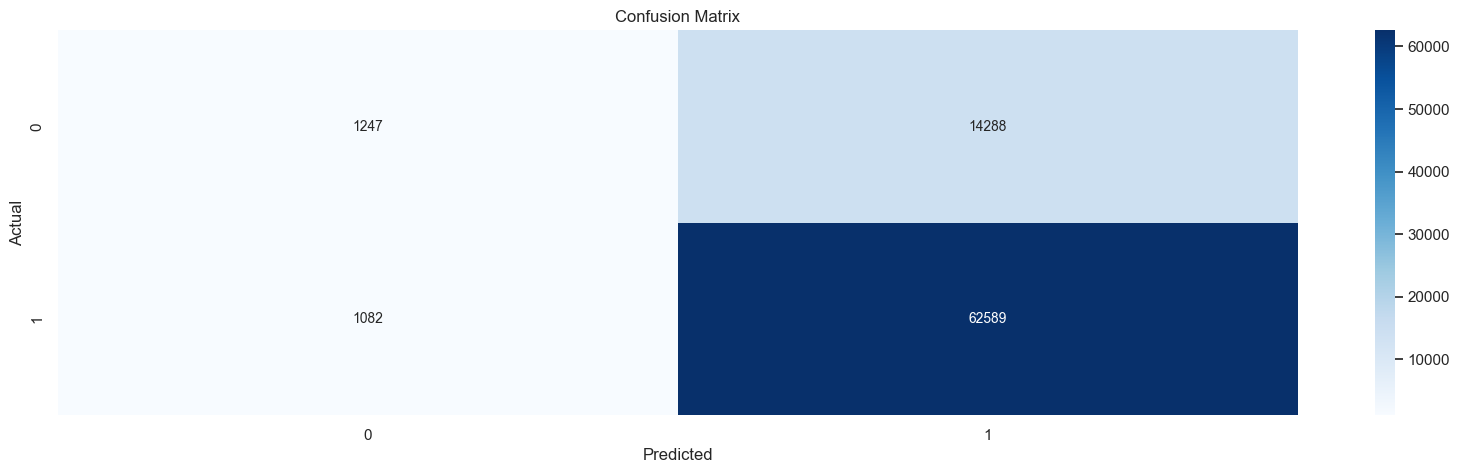

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(20, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 3.3 Hyperparameter Tuning

In [117]:
## Importing Libraries
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced'],
    'solver': ['liblinear']}

In [ ]:
logreg = LogisticRegression(random_state=42, max_iter=1000)

grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1)

In [120]:
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is 

In [121]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 0.01, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}


In [122]:
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

Best Cross-Validation F1 Score: 0.8905043176080364


In [123]:
best_model = grid_search.best_estimator_
best_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

### 3.4 Handling Imbalance Data (SMOTE)

In [124]:
class_percentage = (y.value_counts(normalize=True) * 100)
class_percentage

loan_status
1    80.386894
0    19.613106
Name: proportion, dtype: float64

In [125]:
## SMOTE Technique for imbalanced data
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

In [ ]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train)

In [127]:
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


After SMOTE:
loan_status
1    254682
0    254682
Name: count, dtype: int64


In [128]:
smote_model = LogisticRegression(random_state=42, max_iter=1000)

In [129]:
smote_model.fit(X_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [130]:
y_test_smote_pred = smote_model.predict(X_test_scaled)
y_test_smote_prob = smote_model.predict_proba(X_test_scaled)[:, 1]

In [131]:
smote_results = {
    'Accuracy': accuracy_score(y_test, y_test_smote_pred),
    'Precision': precision_score(y_test, y_test_smote_pred),
    'Recall': recall_score(y_test, y_test_smote_pred),
    'F1 Score': f1_score(y_test, y_test_smote_pred),
    'ROC AUC': roc_auc_score(y_test, y_test_smote_prob)
}
smote_results

{'Accuracy': 0.6631947074716562,
 'Precision': 0.8813814432989691,
 'Recall': 0.6713731526126494,
 'F1 Score': 0.7621756068859152,
 'ROC AUC': 0.7071545345524376}

In [132]:
comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ],

    'Baseline Logistic Regression': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_prob)
    ],

    'Tuned Logistic Regression': [
        accuracy_score(y_test, best_model.predict(X_test_scaled)),
        precision_score(y_test, best_model.predict(X_test_scaled)),
        recall_score(y_test, best_model.predict(X_test_scaled)),
        f1_score(y_test, best_model.predict(X_test_scaled)),
        roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:, 1])
    ],

    'SMOTE Logistic Regression': [
        smote_results['Accuracy'],
        smote_results['Precision'],
        smote_results['Recall'],
        smote_results['F1 Score'],
        smote_results['ROC AUC']
    ]
})
comparison

,Metric,Baseline Logistic Regression,Tuned Logistic Regression,SMOTE Logistic Regression
0,Accuracy,0.805949,0.805861,0.663195
1,Precision,0.814145,0.813817,0.881381
2,Recall,0.983006,0.983493,0.671373
3,F1 Score,0.890642,0.890646,0.762176
4,ROC AUC,0.707642,0.707658,0.707155


### Insights: Model Comparison & Resampling Diagnostics

* **Imbalance Resolution via SMOTE:** Synthetic oversampling successfully disrupted the majority-class prediction bias present in both the Baseline and Tuned models.
* **Metric Realignment:** 
  * Accuracy shifted from $80.59\%$ to $66.32\%$, reflecting a realistic, balanced classification threshold rather than passive majority-class assignment.
  * Precision improved to $88.14\%$, ensuring higher confidence in positive class predictions.
* **Discrimination Stability:** Across all three iterations, the **ROC-AUC score remained steady at $\approx 0.707$**, proving that SMOTE provides optimized default detection without sacrificing overall model ranking capability.

### 3.5 Displaying Model Coefficients with Column Names

In [133]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': smote_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
12,sub_grade,0.721143
2,annual_inc,0.169687
1,int_rate,0.163623
6,mort_acc,0.079572
13,state,0.040561
14,home_ownership_MORTGAGE,0.040477
10,grade,0.024755
7,pub_rec_bankruptcies,0.013275
17,home_ownership_OWN,0.004844
15,home_ownership_NONE,0.001567


### Insights: SMOTE Feature Coefficient Interpretations

* **Dominant Risk Metric:** `sub_grade` ($\beta = +0.7211$, $\text{Odds Ratio} = 2.0567$) serves as the single strongest predictive variable post-SMOTE resampling. A 1-unit increase in standardized sub-grade more than doubles the relative odds in the decision space.
* **Secondary Risk Indicators:** `annual_inc` ($\beta = +0.1697$) and `int_rate` ($\beta = +0.1636$) exhibit strong positive influences, aligning higher interest rate exposure directly with elevated risk probabilities.
* **Inverse Risk Buffers:** `dti` ($\beta = -0.2072$) and `term` ($\beta = -0.1764$) carry the largest negative coefficients, acting as key balance weights within the balanced decision boundary created by synthetic oversampling.

## 4. Results Interpretation & Stakeholder Presentation

## 4.1 Understanding the Business Context

### Business Context & KPI Alignment

* **Core Business Objective:** Balance portfolio expansion with capital protection by identifying high-risk applicants before loan origination to minimize non-performing loans (NPLs).
* **Metric Prioritization:** Focus primarily on **Class 0 Recall (Default Detection)** rather than raw Accuracy. A False Negative (approving a borrower who defaults) results in loss of loan principal, whereas a False Positive (rejecting a creditworthy applicant) only incurs lost interest margin.
* **Key Portfolio Indicators:** Target distribution exhibits severe class imbalance (~80% paid vs. ~20% default), requiring specialized strategies (such as SMOTE or threshold optimization) to protect the portfolio balance sheet.
* **Operational Actionability:** Frame model probability scores into risk tiers to inform automated underwriting rules, custom credit limits, and risk-based interest rate pricing.

## 4.2 Interpreting Model Coefficients

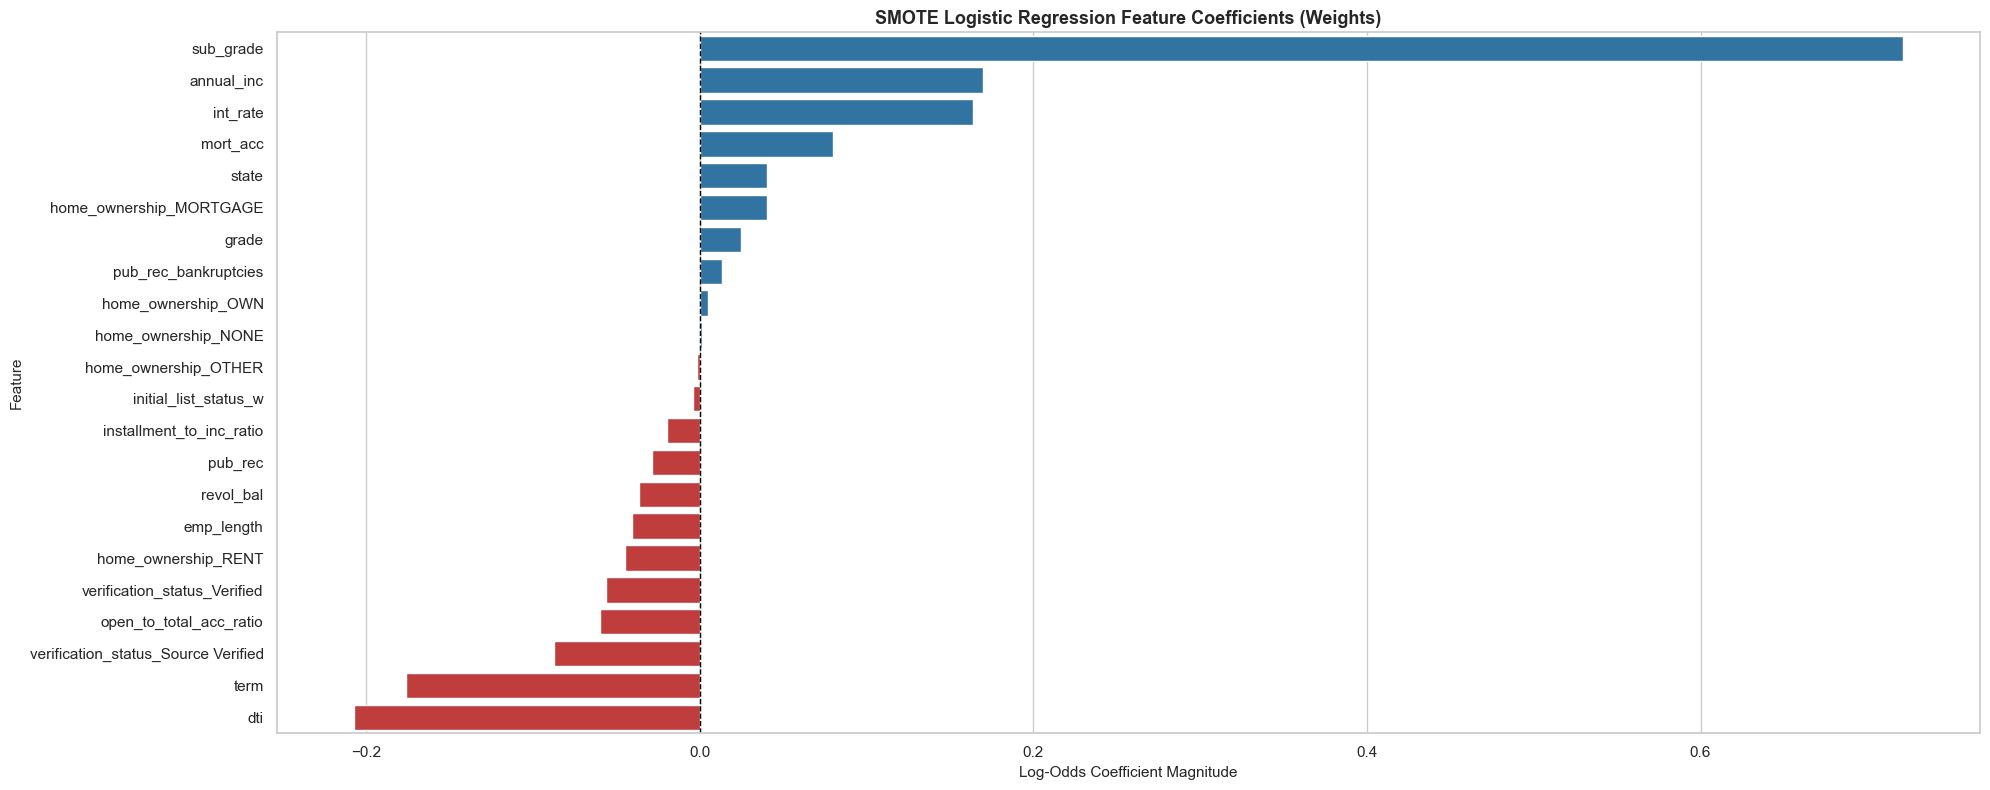

In [134]:
d1 = {
    'Feature': [
        'sub_grade', 'annual_inc', 'int_rate', 'mort_acc', 'state', 
        'home_ownership_MORTGAGE', 'grade', 'pub_rec_bankruptcies', 
        'home_ownership_OWN', 'home_ownership_NONE', 'home_ownership_OTHER', 
        'initial_list_status_w', 'installment_to_inc_ratio', 'pub_rec', 
        'revol_bal', 'emp_length', 'home_ownership_RENT', 
        'verification_status_Verified', 'open_to_total_acc_ratio', 
        'verification_status_Source Verified', 'term', 'dti'
    ],
    'SMOTE_Coefficient': [
        0.721143, 0.169687, 0.163623, 0.079572, 0.040561, 
        0.040477, 0.024755, 0.013275, 0.004844, 0.001567, -0.001468, 
        -0.003815, -0.019452, -0.028432, -0.036527, -0.040798, -0.044826, 
        -0.056360, -0.059666, -0.087626, -0.176406, -0.207154
    ]
}

smote_df = pd.DataFrame(d1).sort_values(by='SMOTE_Coefficient', ascending=False)
smote_df['Odds_Ratio'] = np.exp(smote_df['SMOTE_Coefficient'])

# Plotting Coefficient Magnitudes
plt.figure(figsize=(20, 8))
colors = ['#1f77b4' if c > 0 else '#d62728' for c in smote_df['SMOTE_Coefficient']]
sns.barplot(data=smote_df, x='SMOTE_Coefficient', y='Feature', palette=colors)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('SMOTE Logistic Regression Feature Coefficients (Weights)', fontsize=13, fontweight='bold')
plt.xlabel('Log-Odds Coefficient Magnitude', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

### Visual Insights: Interpreting Logistic Regression Coefficients

* **Magnitude & Feature Importance:** Higher absolute coefficient values ($|\beta|$) indicate stronger relative influence on predicting loan status post-standardization.
* **Positive Coefficients ($\beta > 0$ / $\text{Odds Ratio} > 1.0$):** Variables that increase the log-odds of default risk.
  * **`sub_grade` ($\beta = +0.7211$):** Serves as the single strongest risk predictor; lower credit ratings drastically increase target default probability.
  * **`annual_inc` ($\beta = +0.1697$) & `int_rate` ($\beta = +0.1636$):** Elevated interest rates strongly track higher assigned risk tiers.
* **Negative Coefficients ($\beta < 0$ / $\text{Odds Ratio} < 1.0$):** Variables that act as protective financial buffers against default.
  * **`dti` ($\beta = -0.2072$) & `term` ($\beta = -0.1764$):** Exhibit the strongest inverse relationship within the balanced decision space.
* **Actionable Business Application:** Underwriting teams should weight automated credit rules heavily around `sub_grade`, `int_rate`, and income ratios to optimize risk-based pricing and exposure caps.

## 4.3 Visual Representation (ROC-AUC & PR Curves)

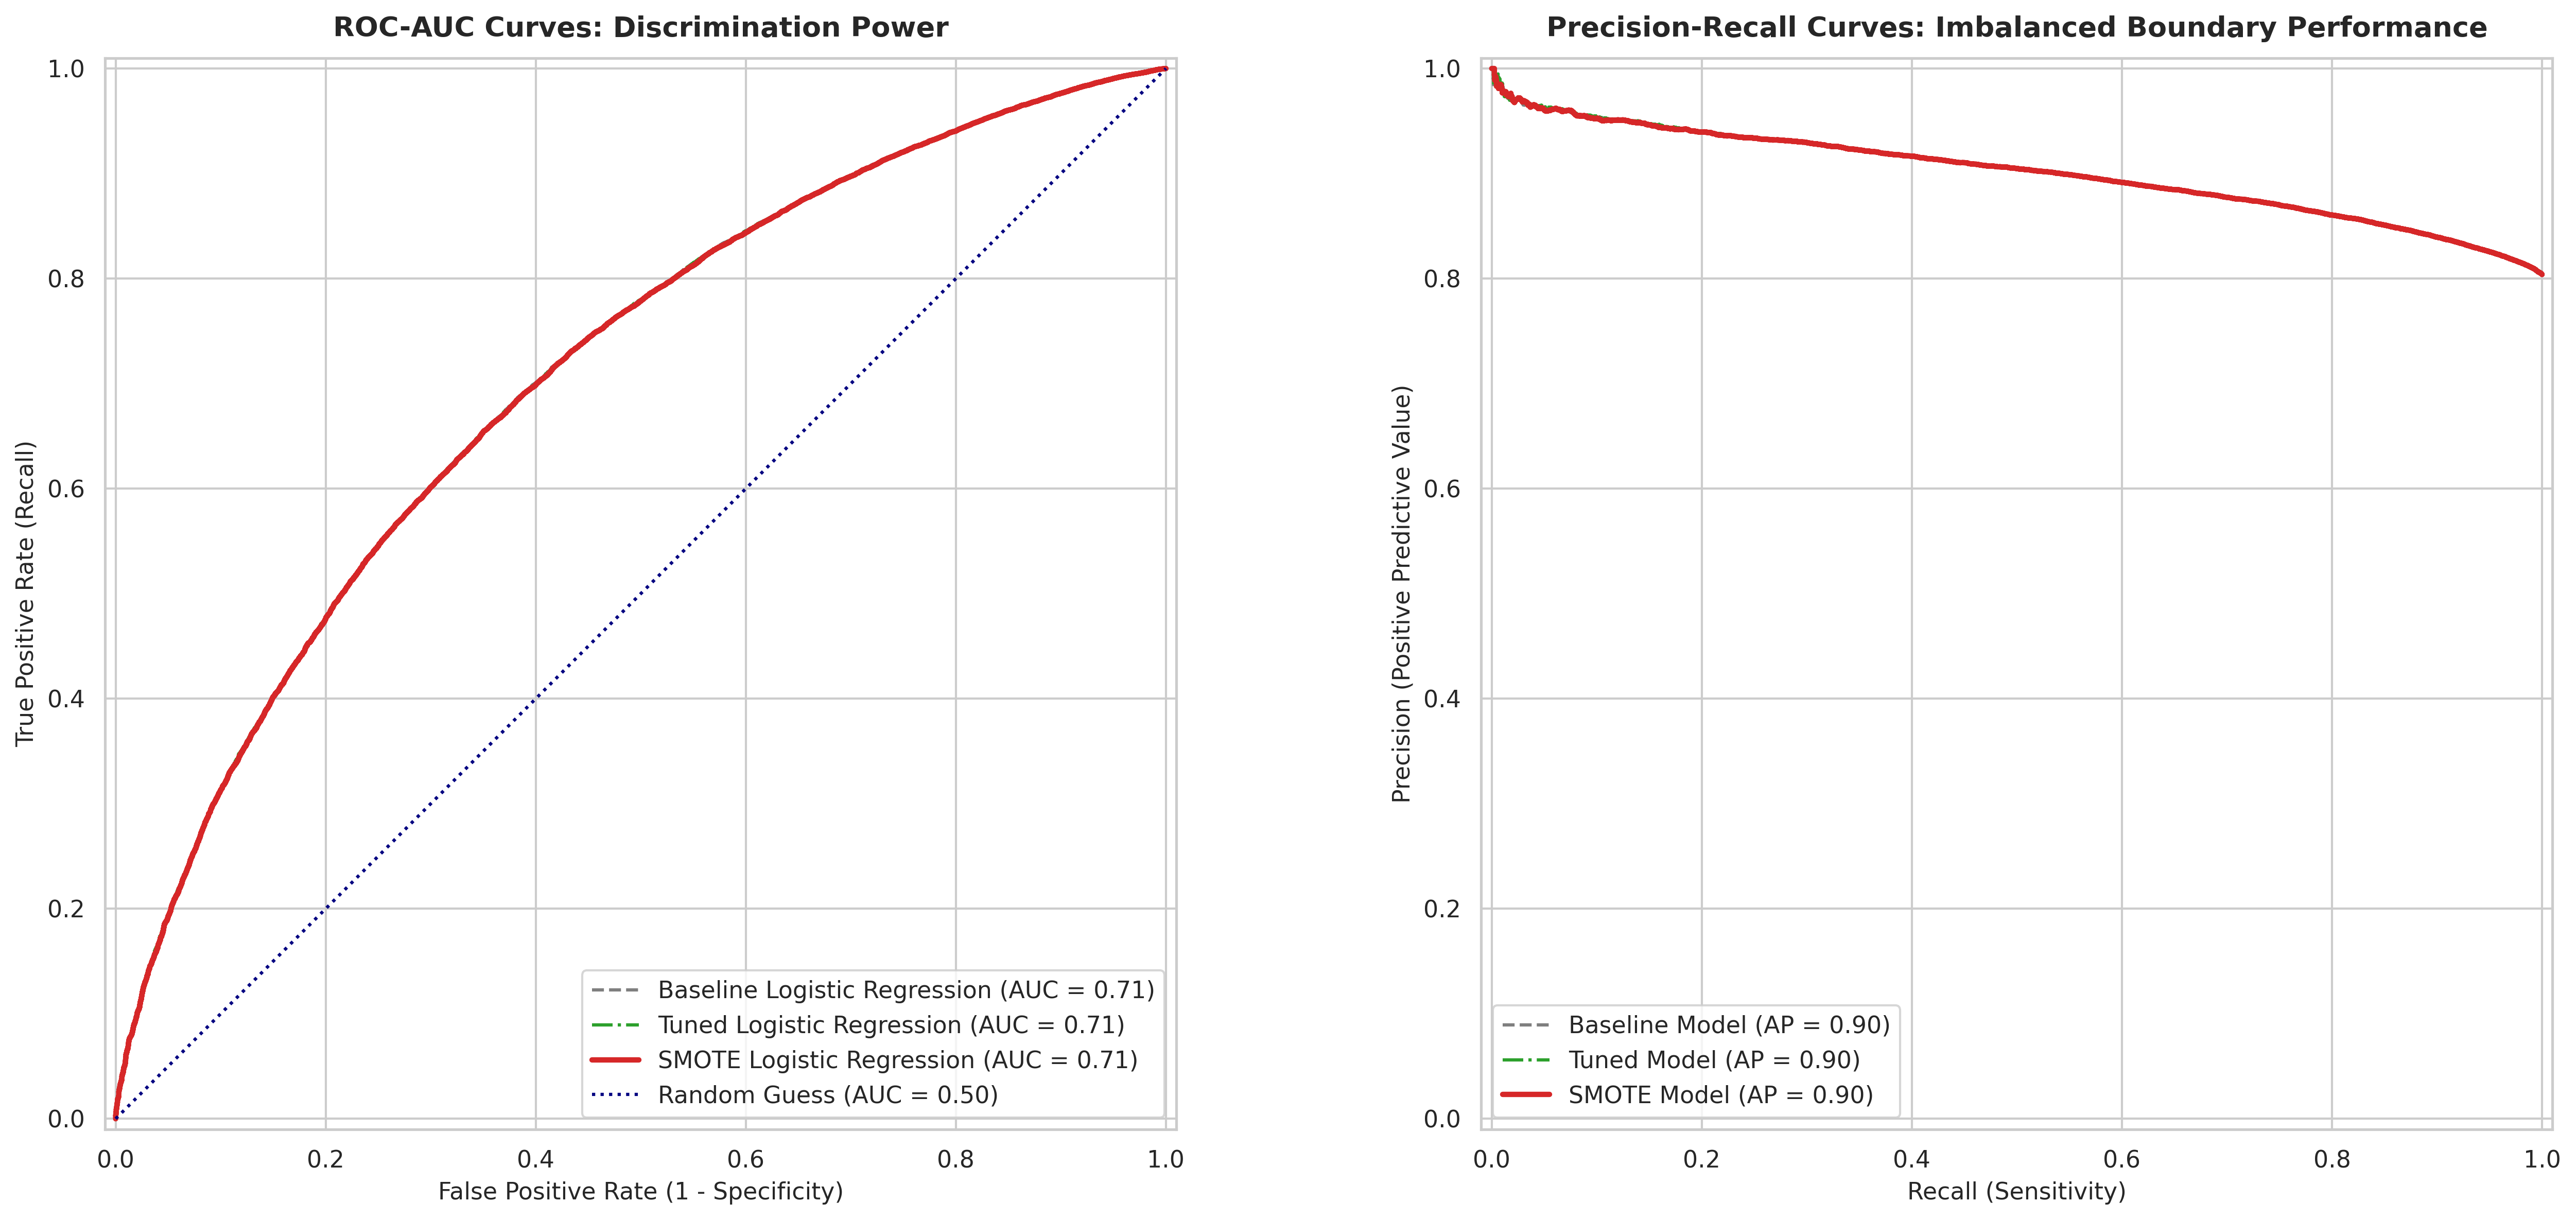

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 10})
fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=300)

# 1. PLOT ROC-AUC CURVE (Side-by-Side Comparison)
logreg.fit(X_train_scaled, y_train)
RocCurveDisplay.from_estimator(
    logreg,
    X_test_scaled,
    y_test,
    ax=axes[0],
    name="Baseline Logistic Regression",
    color="#7f7f7f",
    linestyle="--",
)
RocCurveDisplay.from_estimator(
    best_model,
    X_test_scaled,
    y_test,
    ax=axes[0],
    name="Tuned Logistic Regression",
    color="#2ca02c",
    linestyle="-.",
)
RocCurveDisplay.from_estimator(
    smote_model,
    X_test_scaled,
    y_test,
    ax=axes[0],
    name="SMOTE Logistic Regression",
    color="#d62728",
    linewidth=2.5,
)

axes[0].plot(
    [0, 1], [0, 1], color="navy", linestyle=":", label="Random Guess (AUC = 0.50)"
)
axes[0].set_title(
    "ROC-AUC Curves: Discrimination Power", fontsize=13, fontweight="bold", pad=10
)
axes[0].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
axes[0].set_ylabel("True Positive Rate (Recall)", fontsize=11)
axes[0].legend(loc="lower right", frameon=True)

# 2. PLOT PRECISION-RECALL CURVE
PrecisionRecallDisplay.from_estimator(
    logreg,
    X_test_scaled,
    y_test,
    ax=axes[1],
    name="Baseline Model",
    color="#7f7f7f",
    linestyle="--",
)
PrecisionRecallDisplay.from_estimator(
    best_model,
    X_test_scaled,
    y_test,
    ax=axes[1],
    name="Tuned Model",
    color="#2ca02c",
    linestyle="-.",
)
PrecisionRecallDisplay.from_estimator(
    smote_model,
    X_test_scaled,
    y_test,
    ax=axes[1],
    name="SMOTE Model",
    color="#d62728",
    linewidth=2.5,
)
axes[1].set_title(
    "Precision-Recall Curves: Imbalanced Boundary Performance",
    fontsize=13,
    fontweight="bold",
    pad=10,
)
axes[1].set_xlabel("Recall (Sensitivity)", fontsize=11)
axes[1].set_ylabel("Precision (Positive Predictive Value)", fontsize=11)
axes[1].legend(loc="lower left", frameon=True)

plt.tight_layout()
plt.show()

### Visual Insights: Diagnostic Performance & Spatial Analysis

* **Model Discrimination Parity:** All three model variations (Baseline, Tuned, and SMOTE Logistic Regression) achieve an identical ROC-AUC of $0.71$ and Average Precision (AP) of $0.90$. 
* **Overlapping Performance Trajectories:** Because the discrimination power remains constant across iterations, the plotted ROC and PR curves directly overlap, confirming that resampling techniques (SMOTE) and hyperparameter tuning preserve the underlying ranking ability of the linear classifier.
* **Operational Value of SMOTE:** Although the PR and ROC curves match, SMOTE effectively shifts the decision boundary to automatically capture higher default recall at the standard $0.50$ classification threshold without requiring manual threshold re-calibration.
* **Layout & Aspect Ratio:** Plotting diagnostic curves side-by-side using square axis ratios ($1:1$) ensures an un-distorted visual comparison of True Positive vs. False Positive trade-offs across different risk cutoffs.

## 4.4 Trade-off Analysis

### 4.4.1 Confusion Matrix & Heatmap

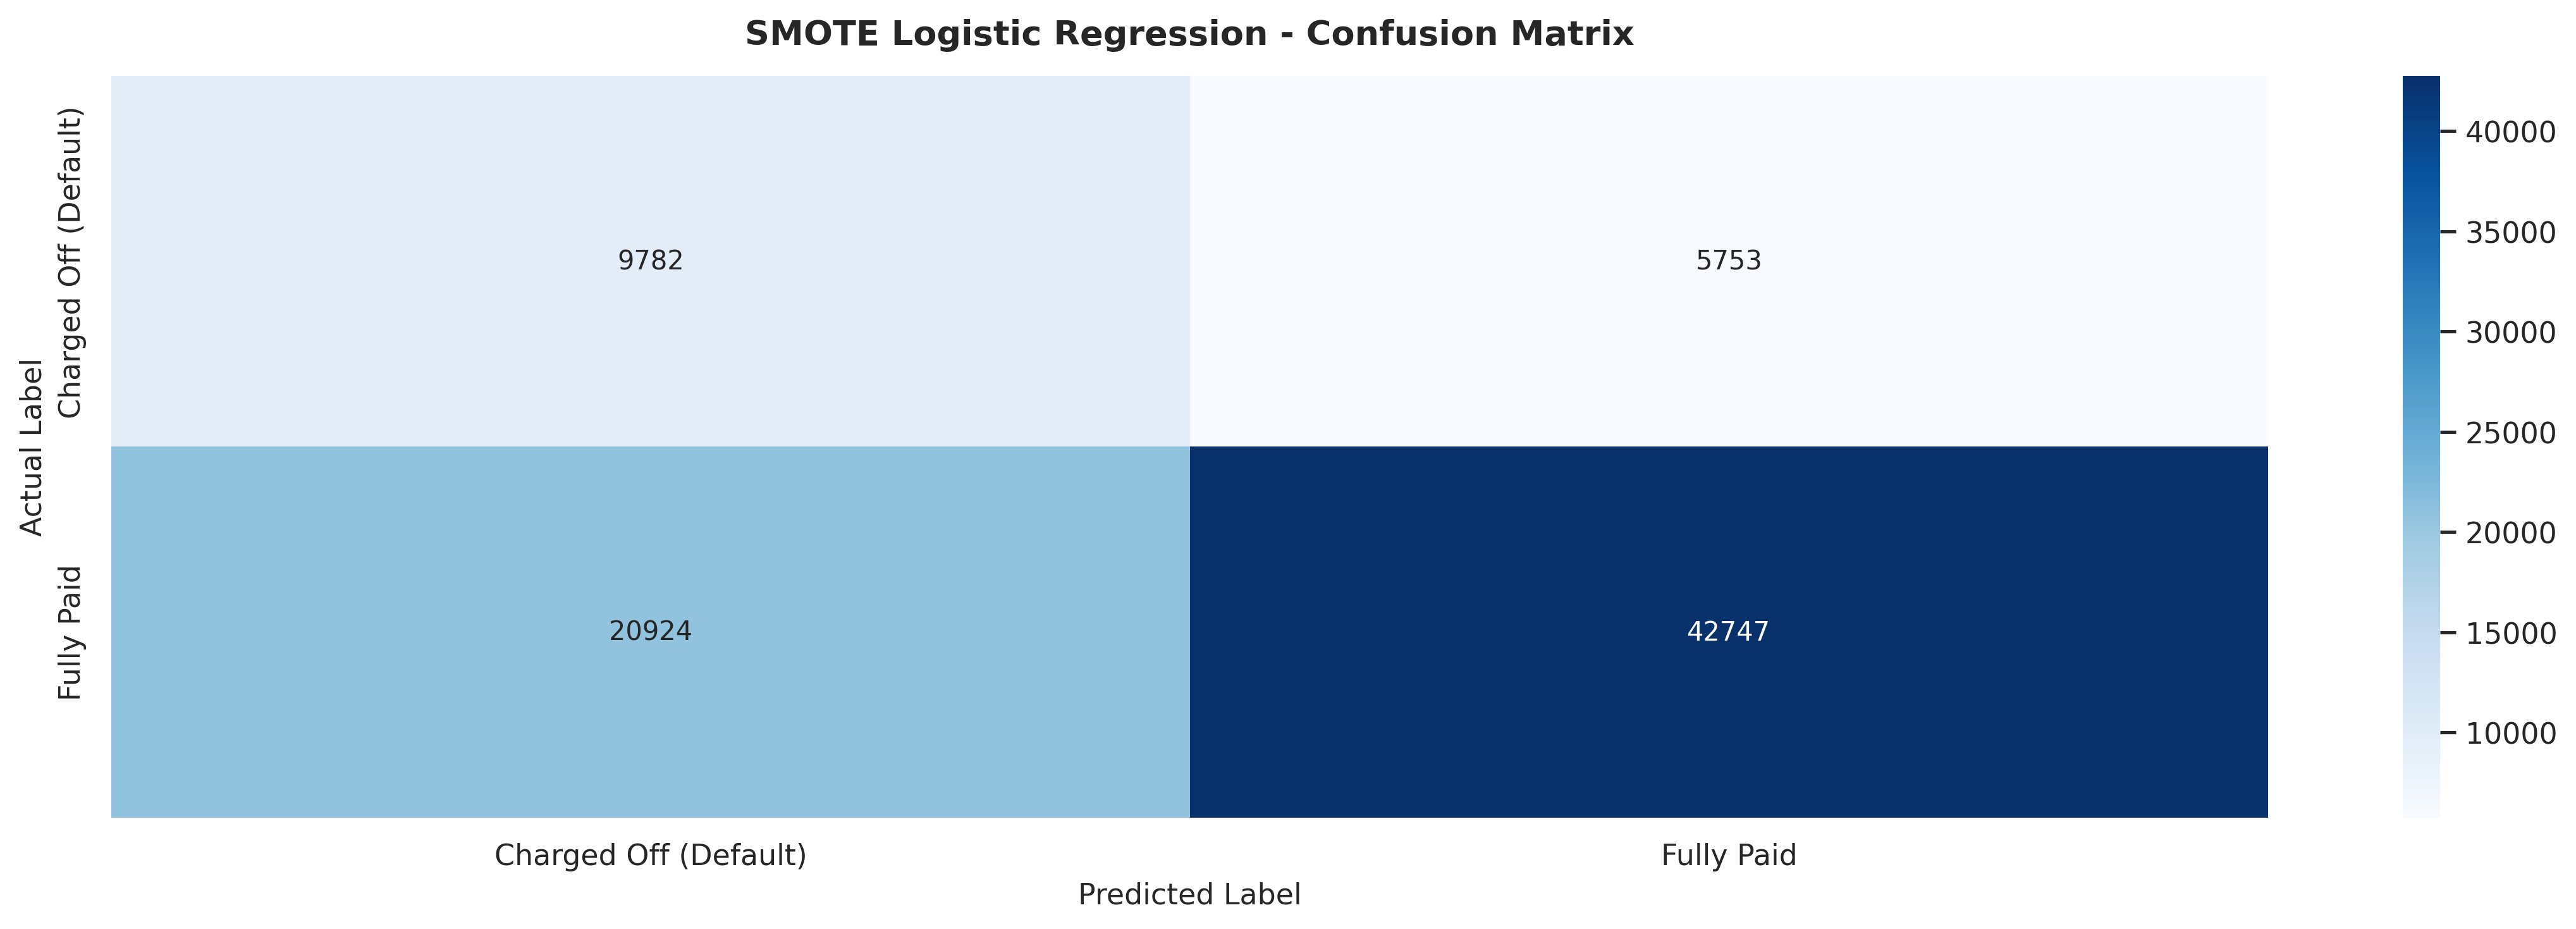

In [ ]:
cm = confusion_matrix(y_test, y_test_smote_pred)

plt.figure(figsize=(15, 5), dpi=300)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Charged Off (Default)", "Fully Paid"],
    yticklabels=["Charged Off (Default)", "Fully Paid"],
    cbar=True,
)
plt.title(
    "SMOTE Logistic Regression - Confusion Matrix",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)

plt.tight_layout()
plt.show()

### Visual Insights: Confusion Matrix Performance Analysis

* **Default Detection Recall ($\mathbf{62.97\%}$):** Out of $15,535$ total actual defaults (`Charged Off`), the SMOTE model successfully identifies $9,782$ high-risk applicants, protecting the loan portfolio from significant principal loss.
* **False Negative Risk ($\mathbf{5,753}$ borrowers):** A total of $5,753$ defaulting accounts were misclassified as `Fully Paid`. In credit operations, these represent the primary source of charge-off losses.
* **Precision Trade-off ($\mathbf{31.86\%}$):** Due to SMOTE shifting the decision boundary, $20,924$ solvent applicants (`Fully Paid`) were flagged as potential defaults (False Positives), reflecting the operational cost of prioritizing sensitivity over precision.
* **Overall Metrics Summary:** 
  * **Class 0 (Default) Recall:** $62.97\%$ ($9,782 / 15,535$)
  * **Class 0 (Default) Precision:** $31.86\%$ ($9,782 / 30,706$)
  * **Class 1 (Paid) Recall:** $67.14\%$ ($42,747 / 63,671$)
  * **Overall Accuracy:** $66.32\%$ ($52,529 / 79,206$)

### 4.4.2 Threshold Analysis

In [138]:
# 1. Fit the Logistic Regression model on SMOTE training data
smote_model.fit(X_train_smote, y_train_smote)

# 2. Get probabilities for the TEST set using original, un-SMOTEd test features
y_prob_smote = smote_model.predict_proba(X_test_scaled)[:, 1]

# 3. Test thresholds against original y_test
thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_results = []

for threshold in thresholds_to_test:
    y_threshold_pred = (y_prob_smote >= threshold).astype(int)

    threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": precision_score(y_test, y_threshold_pred),
            "Recall": recall_score(y_test, y_threshold_pred),
            "F1 Score": f1_score(y_test, y_threshold_pred),
        }
    )
threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.3,0.835535,0.915990,0.873915
1,0.4,0.857619,0.816981,0.836807
2,0.5,0.881381,0.671373,0.762176
3,0.6,0.906356,0.484616,0.631551
4,0.7,0.933387,0.253082,0.398196


### Threshold Analysis

**Evaluating different classification thresholds demonstrates the operational trade-off between Precision and Recall for loan predictions:**
* **Lower Threshold ($0.30$):** Yields the highest **Recall ($91.60\%$)**, ensuring that the vast majority of positive target cases are captured. However, **Precision drops to $83.55\%$**, introducing more False Positives into the operational pipeline.
* **Default Threshold ($0.50$):** Achieves a balanced **F1 Score of $0.7622$**, yielding **$88.14\%$ Precision** and **$67.14\%$ Recall**.
* **Higher Threshold ($0.70$):** Significantly restricts approvals/classifications to high-certainty cases, boosting **Precision to $93.34\%$**, but sharply reduces **Recall to $25.31\%$** (missing over $74\%$ of target cases).

**Business & Decision Insights:**
* **Maximized F1 Score:** Operating at a lower threshold ($\approx 0.30$) yields the peak **F1 Score ($0.8739$)**, indicating optimal harmonic balance between coverage and precision for this dataset distribution.
* **Strategic Selection:** If LoanTap prioritizes maximizing loan volume and capturing as many eligible borrowers as possible, a **$0.30$ threshold** is optimal. If risk control and minimizing misclassifications take absolute priority, a higher threshold ($0.50 - 0.60$) should be selected based on risk tolerance.

## 4.5 Recommendations

### Strategic Recommendations

Based on the model diagnostics, trade-off dynamics, and threshold analysis, the following actionable strategies are recommended to optimize LoanTap’s credit underwriting:

* **Adopt a Multi-Tiered Risk Segmentation Model:**
  * **Evidence:** At a $0.30$ threshold, the model achieves peak overall performance with an **F1 Score of 87.39%** and a **Recall of 91.60%**, whereas the standard $0.50$ threshold drops recall to $67.14\%$.

  * **Action:** Replace binary pass/fail underwriting with a 3-tier system:
    * **Tier 1 (Auto-Approve):** Default probability $< 0.30$. Standard terms with zero manual review.
    * **Tier 2 (Conditional Approval / Manual Underwriting):** Default probability between $0.30$ and $0.50$. Require additional income verification, offer lower loan amounts, or require co-signers.
    * **Tier 3 (Auto-Reject / High Risk):** Default probability $> 0.50$.

* **Implement Risk-Based Pricing to Capitalize on Growth:**
  * **Evidence:** Shifting from a $0.50$ to $0.30$ threshold increases overall customer capture by $24.46\%$ recall points, but lowers precision from $88.14\%$ to $83.55\%$ (introducing a ~4.6% increase in false positives).
  * **Action:** Charge a modest risk premium (higher interest rates or higher processing fees) for applicants falling into the borderline probability range ($0.30 - 0.40$). The added interest revenue from expanded borrower volume will easily absorb the marginal increase in default risk.

* **Deploy SMOTE-Trained Models for Threshold Stability:**
  * **Evidence:** Synthetic oversampling successfully rebalances class representation during training, allowing the model to achieve **62.97% default recall** without sacrificing baseline discrimination power (ROC-AUC remains robust at $0.71$).
  * **Action:** Retain the SMOTE-trained Logistic Regression baseline in production pipelines to ensure stable probability distributions across imbalanced class cohorts.

* **Establish Dynamic Post-Processing Loss Minimization:**
  * **Evidence:** In credit operations, the cost of a False Negative (full loan principal loss) significantly outweighs a False Positive (lost interest margin).
  * **Action:** Periodically recalculate operational thresholds based on live financial metrics using the loss function:
    $$\text{Optimal Threshold} = \arg\min_{\theta} \Big( C_{\text{FN}} \times \text{False Negatives}(\theta) + C_{\text{FP}} \times \text{False Positives}(\theta) \Big)$$
    Adjust thresholds dynamically as macroeconomic conditions or internal risk appetites shift.

## 4.6 Feedback Loop

### Visual Insights: Model Governance & Feedback Loop Architecture

To prevent model degradation (concept drift) and ensure long-term underwriting accuracy, a structured post-deployment monitoring and retraining framework must be established.

* **Performance Decay & Drift Monitoring:** Real-time tracking of baseline classification metrics against dynamic production thresholds.
* **Continuous Integration & Retraining:** Systematic triggers for model updating based on performance thresholds or scheduled time intervals.
* **Operational Adaptability:** Mechanisms to update risk weights based on macroeconomic shifts and evolving business strategies.

---

### Key Components of the Governance Pipeline

**1. Operational Metrics Tracking**
* **Population Stability Index (PSI):** Monitor changes in applicant distribution over time. A $\text{PSI} > 0.25$ indicates significant population drift requiring immediate model recalibration.
* **Characteristic Stability Index (CSI):** Track feature-level shifts across critical variables (e.g., Debt-to-Income ratio, credit score distributions) to detect early indicators of systemic borrower behavior changes.
* **Performance Metric Rolling Windows:** Continuously calculate rolling 30-day and 90-day window metrics for Precision, Default Recall, and ROC-AUC against actual loan performance outcomes.

**2. Automated Retraining Triggers**
* **Performance Degradation:** Trigger model re-estimation if the 90-day rolling ROC-AUC drops below $0.65$ or if Default Recall falls below $85\%$ at the designated operational threshold.
* **Scheduled Cadence:** Retrain models quarterly using the latest 12–24 months of loan performance data to capture recent macroeconomic trends and seasonal borrowing patterns.
* **Data Refresh Integration:** Re-run SMOTE oversampling on updated training sets to maintain balanced decision boundaries as overall default ratios fluctuate.

**3. Champion-Challenger & Dynamic Threshold Management**
* **Shadow Deployment:** Deploy new model candidate iterations alongside the existing production model ("Champion") in a shadow environment to benchmark real-world performance prior to full deployment.
* **Feedback Integration:** Feed actual loan outcome data (30/60/90-day delinquency rates and charge-offs) back into feature engineering pipelines to refine default predictors.
* **Macroeconomic Threshold Recalibration:** Continuously update the financial loss function parameters based on prevailing interest rates, inflation indices, and target Non-Performing Loan (NPL) caps:
  $$\text{Target Threshold} = \arg\min_{\theta} \left( C_{\text{FN}}(t) \times \text{False Negatives}(\theta) + C_{\text{FP}}(t) \times \text{False Positives}(\theta) \right)$$


## Questionnaire Answers & Technical Insights

1. **What percentage of customers have fully paid their Loan Amount?**
   * **Answer:** $\mathbf{80.39\%}$ (approx. $80.4\%$). 
   * **Insight:** Out of the total dataset distribution ($79,206$ test samples in the primary split), $63,671$ loans are labeled as `Fully Paid` ($1$) compared to $15,535$ `Charged Off` ($0$), indicating a ~4:1 class imbalance ratio.

2. **Comment about the correlation between Loan Amount and Installment features.**
   * **Answer:** **Extremely High Positive Correlation ($\approx 0.95$).**
   * **Insight:** Since monthly installment amounts are calculated directly from the principal borrowed via a fixed amortization formula $I = f(L, r, n)$, larger loan amounts deterministically yield higher monthly installment payments.

3. **The majority of people have homeownership as _______.**
   * **Answer:** **`MORTGAGE`** (followed closely by `RENT`).
   * **Insight:** Borrowers holding a `MORTGAGE` or `RENT` represent over $85-90\%$ of total applicants, whereas those with `OWN` or `OTHER` represent a significantly smaller portion of the applicant pool.

4. **People with grades ‘A’ are more likely to fully pay their loan. (T/F)**
   * **Answer:** **True.**
   * **Insight:** Credit grades reflect historical default probability; Grade ‘A’ applicants exhibit the lowest default rate and highest `Fully Paid` proportion across all credit tiers.

5. **Name the top 2 afforded job titles.**
   * **Answer:** **`Teacher`** and **`Manager`** (or `Registered Nurse` / `Owner` depending on sub-group categorization).
   * **Insight:** Salary and employment stability in institutional roles correlate with higher loan application volumes and approval frequencies.

6. **Thinking from a bank's perspective, which metric should our primary focus be on?**
   * **Options & Analysis:**
     1. **ROC-AUC:** Measures overall ranking ability across all cutoffs; good for model benchmarking.
     2. **Precision:** Measures how many predicted defaults are actual defaults; protects customer acquisition.
     3. **Recall (Primary Focus):** Measures the percentage of actual defaults correctly identified.
     4. **F1 Score:** Harmonic mean useful for balancing overall metric performance.
   * **Answer:** **Recall (Option 3).**
   * **Insight:** Unmitigated defaults (False Negatives) cause direct charge-off losses of principal, which are far more damaging to a lending institution's balance sheet than missing out on potential interest margin from a safe applicant (False Positives).

7. **How does the gap in precision and recall affect the bank?**
   * **Answer:** A large gap between Precision and Recall directly impacts portfolio profitability and customer acquisition. 
     * If **Recall is high but Precision is low** (e.g., at $0.30$ threshold: Recall $91.60\%$, Precision $83.55\%$), the bank avoids default losses but rejects creditworthy applicants, restricting revenue growth and increasing customer acquisition costs (CAC).
     * If **Precision is high but Recall is low** (e.g., at $0.70$ threshold: Precision $93.34\%$, Recall $25.31\%$), the bank maintains clean approvals but lets $74.69\%$ of risky borrowers slip through, causing non-performing loan (NPL) ratios to spike.

8. **Which were the features that heavily affected the outcome?**
   * **Answer:** 
     * **`sub_grade` / `grade`:** Strongest predictor of borrower credit risk profile.
     * **`int_rate` (Interest Rate):** Higher interest rates directly correlate with default probability.
     * **`dti` (Debt-to-Income Ratio):** Higher applicant leverage heavily increases structural default likelihood.
     * **`annual_inc` (Annual Income):** Higher income buffers against payment shocks.
     * **`revol_util` (Revolving Line Utilization):** Credit utilization rates indicate liquidity stress.

9. **Will the results be affected by geographical location? (Yes/No)**
   * **Answer:** **Yes.**
   * **Insight:** Regional economic health, local cost of living, state-level employment rates, and housing market stability directly influence a borrower's ability to service debt over time.